In [265]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from IPython.display import display

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.svm import SVR
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

from xgboost import XGBRegressor

import warnings
warnings.filterwarnings("ignore")

In [266]:
file_path = r"D:\Thesis_Speed_Model\data\Raw\Data Final for Modeling with R1500.xlsx"
df = pd.read_excel(file_path)

In [267]:
df.head()

,SN,V85 Speed,Gradient,Radius of Curve,Carriageway Width,Left Shoulder Width,Left Shoulder Type,Right Shoulder Width,Right Shoulder Type
0,1,57.0,1.27,1500,5.5,0.9,Gravel,0.9,Gravel
1,2,33.0,2.92,46,5.5,0.9,Gravel,0.9,Gravel
2,3,43.0,7.97,1500,5.5,0.9,Gravel,0.9,Gravel
3,4,48.0,2.07,1500,5.5,0.9,Gravel,0.9,Gravel
4,5,36.0,1.21,16,5.5,0.9,Gravel,0.9,Gravel


In [268]:
df.describe()

,SN,V85 Speed,Gradient,Radius of Curve,Carriageway Width,Left Shoulder Width,Right Shoulder Width
count,140.0000,140.000000,140.000000,140.000000,140.000000,140.000000,140.000000
mean,70.5000,46.831786,3.872104,567.314286,6.257550,0.512214,0.521143
std,40.5586,10.353012,2.573637,668.940449,0.936458,0.401510,0.394580
min,1.0000,24.000000,0.100000,15.000000,4.700000,0.000000,0.000000
25%,35.7500,40.812500,1.387500,50.000000,5.500000,0.000000,0.000000
50%,70.5000,46.000000,3.765000,120.000000,7.000000,0.500000,0.500000
75%,105.2500,55.000000,5.985000,1500.000000,7.000000,0.900000,0.907500
max,140.0000,74.000000,10.000000,1500.000000,8.000000,1.130000,1.180000


In [269]:
df.shape

(140, 9)

In [270]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 140 entries, 0 to 139
Data columns (total 9 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   SN                    140 non-null    int64  
 1   V85 Speed             140 non-null    float64
 2   Gradient              140 non-null    float64
 3   Radius of Curve       140 non-null    int64  
 4   Carriageway Width     140 non-null    float64
 5   Left Shoulder Width   140 non-null    float64
 6   Left Shoulder Type    140 non-null    str    
 7   Right Shoulder Width  140 non-null    float64
 8   Right Shoulder Type   140 non-null    str    
dtypes: float64(5), int64(2), str(2)
memory usage: 10.0 KB


In [271]:
df.isnull().sum()

SN                      0
V85 Speed               0
Gradient                0
Radius of Curve         0
Carriageway Width       0
Left Shoulder Width     0
Left Shoulder Type      0
Right Shoulder Width    0
Right Shoulder Type     0
dtype: int64

In [272]:
num_cols = [
    "V85 Speed",
    "Gradient",
    "Carriageway Width",
    "Left Shoulder Width",
    "Right Shoulder Width",
    "Radius of Curve"
]

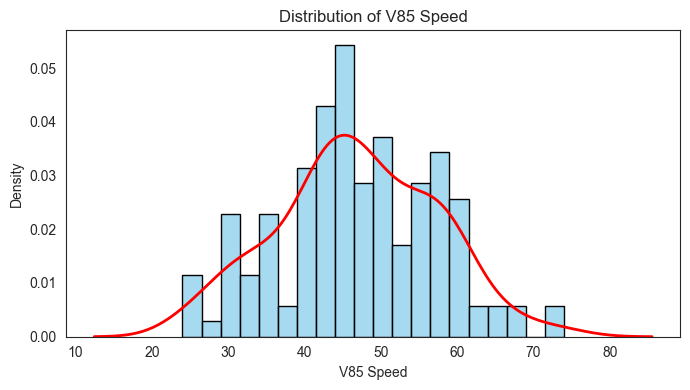

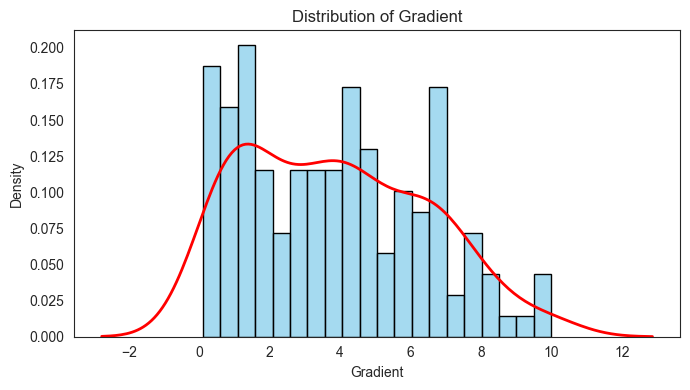

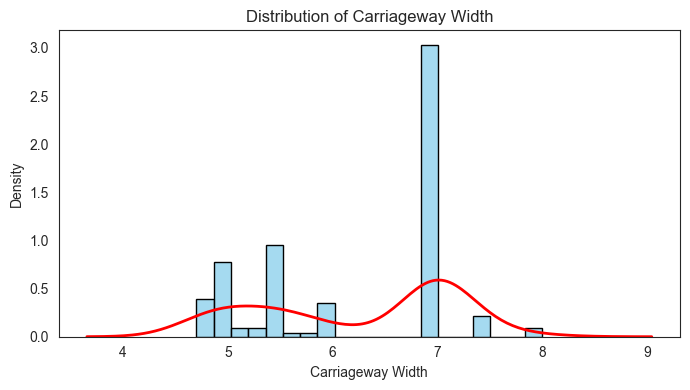

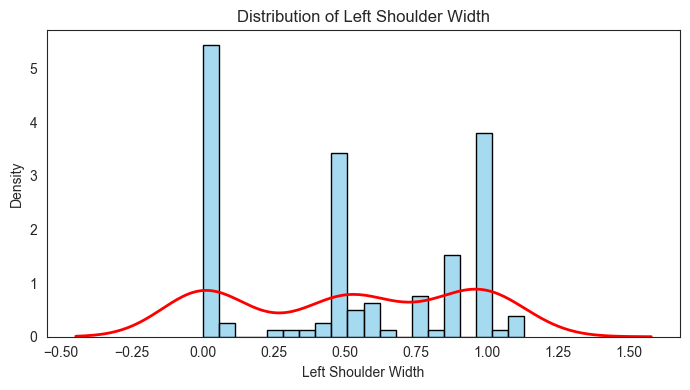

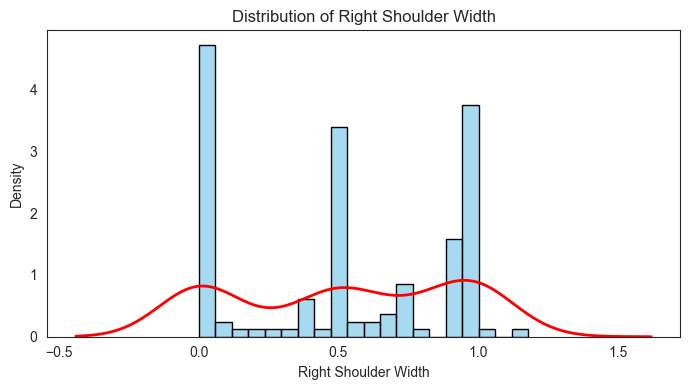

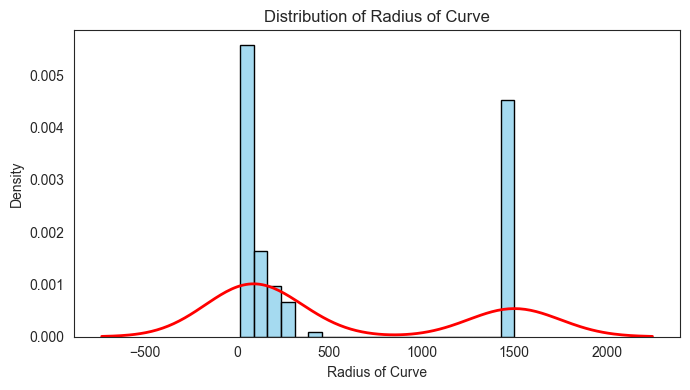

In [273]:
sns.set_style("white")

for col in num_cols:
    plt.figure(figsize=(7,4))

    sns.histplot(df[col], bins=20, stat="density", color="skyblue", edgecolor="black")
    sns.kdeplot(df[col], color="red", linewidth=2)

    plt.title(f"Distribution of {col}")
    plt.xlabel(col)
    plt.ylabel("Density")

    plt.tight_layout()
    plt.show()

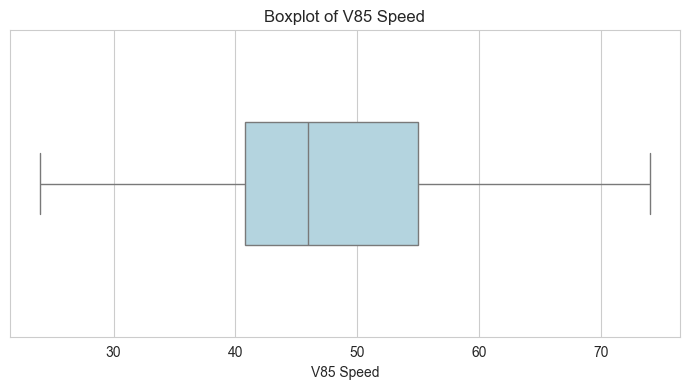

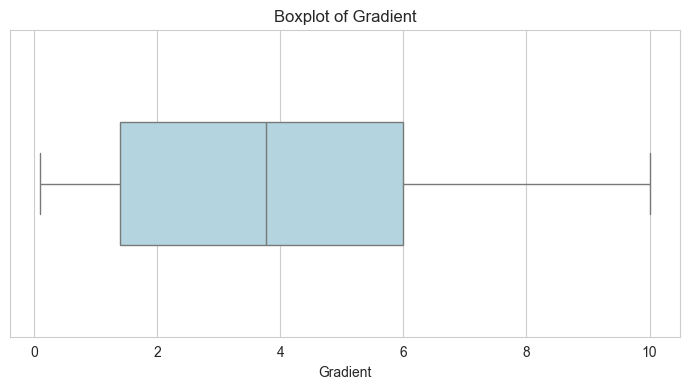

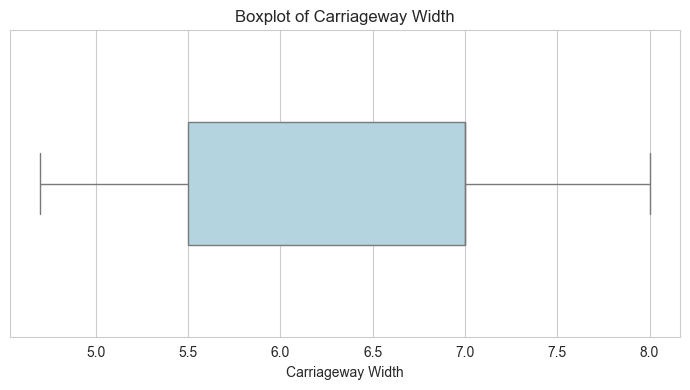

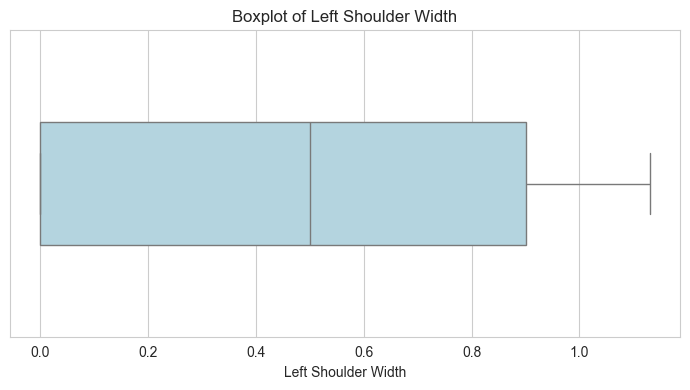

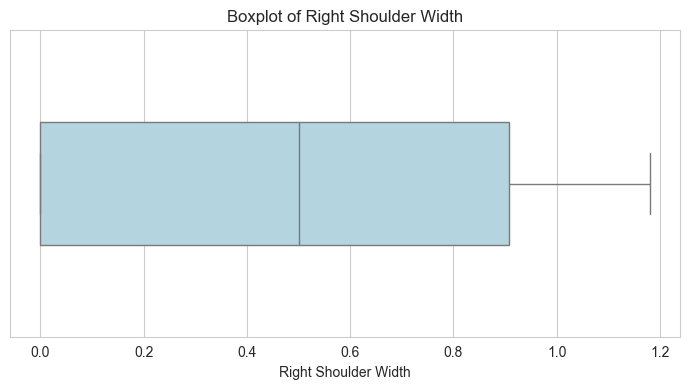

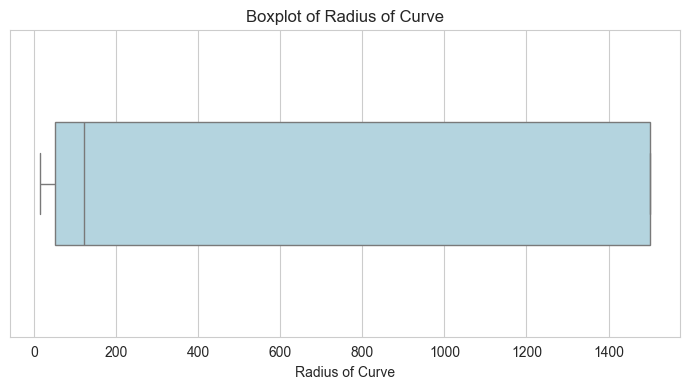

In [274]:
sns.set_style("whitegrid")

for col in num_cols:
    plt.figure(figsize=(7,4))

    sns.boxplot(x=df[col], color="lightblue", width=0.4)

    plt.title(f"Boxplot of {col}")
    plt.xlabel(col)

    plt.tight_layout()
    plt.show()

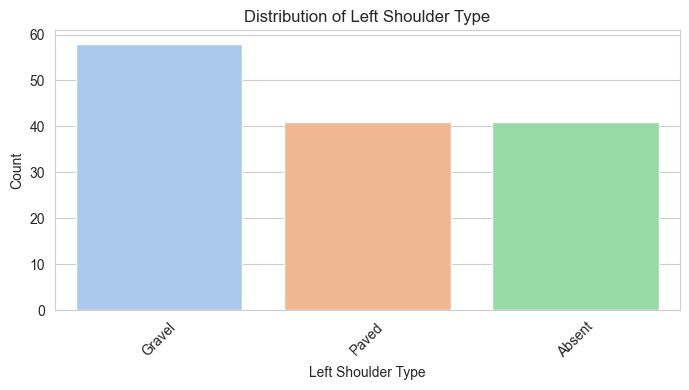

In [275]:
# Clean categorical values
df["Left Shoulder Type"] = df["Left Shoulder Type"].str.strip().str.lower().str.capitalize()

# Plot
sns.set_style("whitegrid")

plt.figure(figsize=(7, 4))
sns.countplot(x=df["Left Shoulder Type"], palette="pastel")

plt.xticks(rotation=45)
plt.title("Distribution of Left Shoulder Type")
plt.xlabel("Left Shoulder Type")
plt.ylabel("Count")

plt.tight_layout()
plt.show()

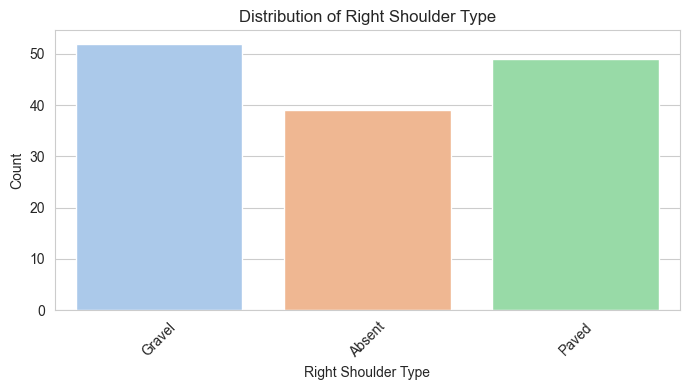

In [276]:
# Clean categorical values
df["Right Shoulder Type"] = df["Right Shoulder Type"].str.strip().str.lower().str.capitalize()

# Plot
sns.set_style("whitegrid")

plt.figure(figsize=(7,4))
sns.countplot(x=df["Right Shoulder Type"], palette="pastel")

plt.xticks(rotation=45)
plt.title("Distribution of Right Shoulder Type")
plt.xlabel("Right Shoulder Type")
plt.ylabel("Count")

plt.tight_layout()
plt.show()

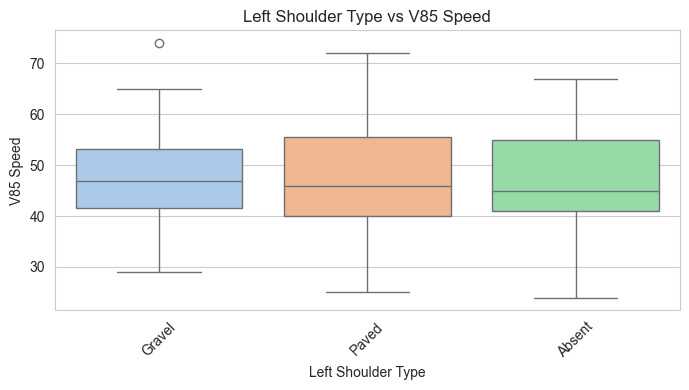

In [277]:
plt.figure(figsize=(7,4))
sns.boxplot(x=df["Left Shoulder Type"], y=df["V85 Speed"], palette="pastel")
plt.xticks(rotation=45)
plt.title("Left Shoulder Type vs V85 Speed")
plt.xlabel("Left Shoulder Type")
plt.ylabel("V85 Speed")
plt.tight_layout()
plt.show()

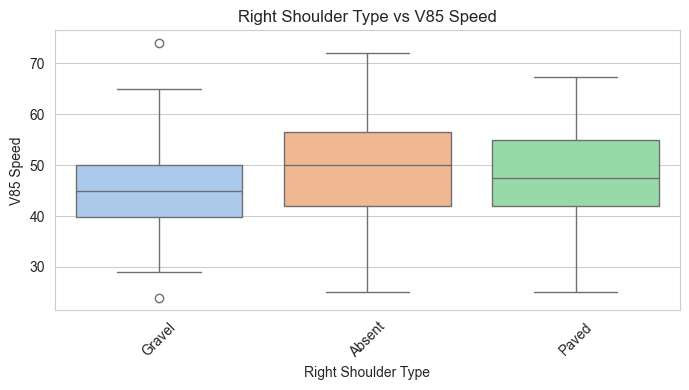

In [278]:
plt.figure(figsize=(7,4))
sns.boxplot(x=df["Right Shoulder Type"], y=df["V85 Speed"], palette="pastel")
plt.xticks(rotation=45)
plt.title("Right Shoulder Type vs V85 Speed")
plt.xlabel("Right Shoulder Type")
plt.ylabel("V85 Speed")
plt.tight_layout()
plt.show()

In [279]:
skew_table = pd.DataFrame({
    "Variable": num_cols,
    "Skewness": df[num_cols].skew().values
})

skew_table

,Variable,Skewness
0,V85 Speed,-0.006374
1,Gradient,0.381686
2,Carriageway Width,-0.339377
3,Left Shoulder Width,-0.098318
4,Right Shoulder Width,-0.135425
5,Radius of Curve,0.671767


In [280]:
corr_matrix = df[num_cols].corr()
corr_matrix

,V85 Speed,Gradient,Carriageway Width,Left Shoulder Width,Right Shoulder Width,Radius of Curve
V85 Speed,1.000000,-0.014513,0.081495,0.025410,-0.039360,0.489553
Gradient,-0.014513,1.000000,-0.177301,-0.167458,-0.176552,-0.152652
Carriageway Width,0.081495,-0.177301,1.000000,0.032165,-0.207924,0.039981
Left Shoulder Width,0.025410,-0.167458,0.032165,1.000000,0.333377,0.142865
Right Shoulder Width,-0.039360,-0.176552,-0.207924,0.333377,1.000000,0.011811
Radius of Curve,0.489553,-0.152652,0.039981,0.142865,0.011811,1.000000


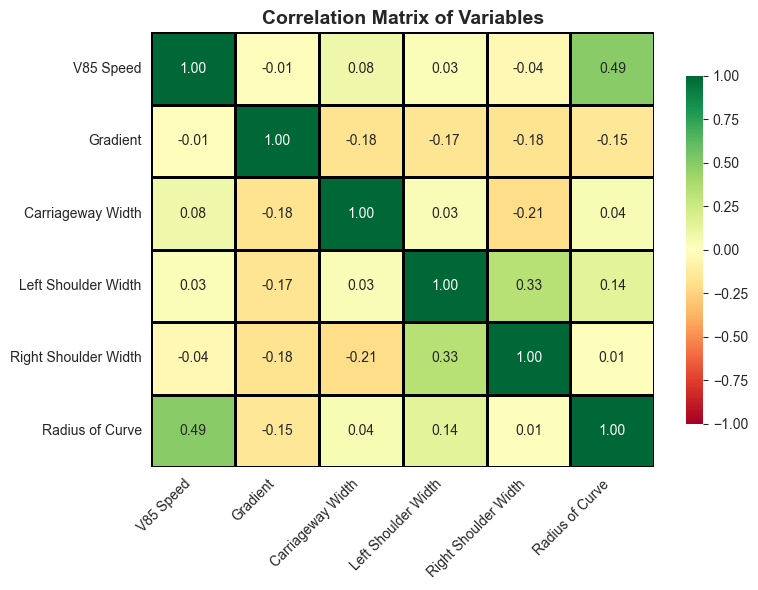

In [281]:
plt.figure(figsize=(8,6))

sns.heatmap(
    corr_matrix,
    annot=True,
    cmap="RdYlGn",        # your preferred colors
    vmin=-1, vmax=1,
    center=0,
    fmt=".2f",
    linewidths=0.8,
    linecolor="black",    # darker grid lines
    cbar_kws={"shrink": 0.8}
)

plt.title("Correlation Matrix of Variables", fontsize=14, fontweight="bold")
plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)

plt.tight_layout()
plt.show()

In [282]:
predictor_cols = [
    "Radius of Curve",
    "Gradient",
    "Carriageway Width",
    "Left Shoulder Width",
    "Right Shoulder Width"
]

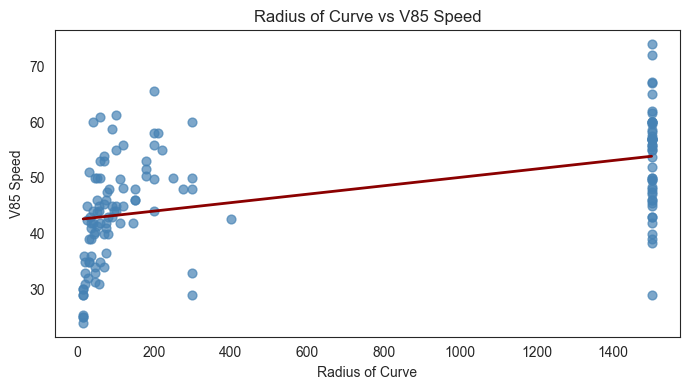

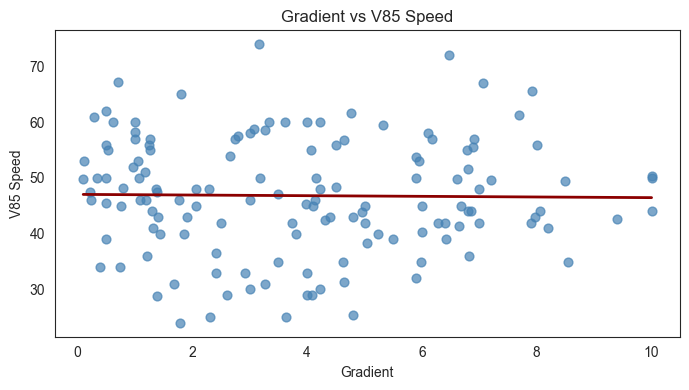

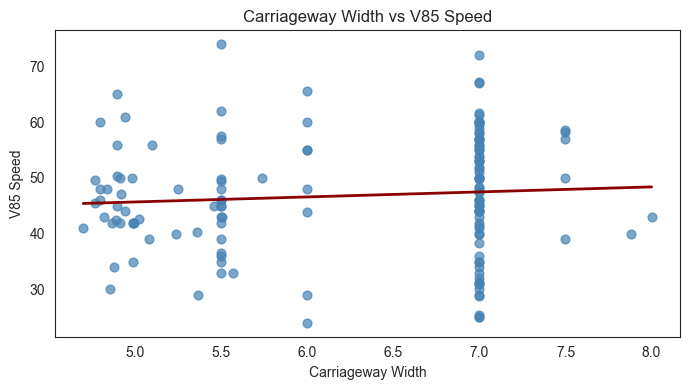

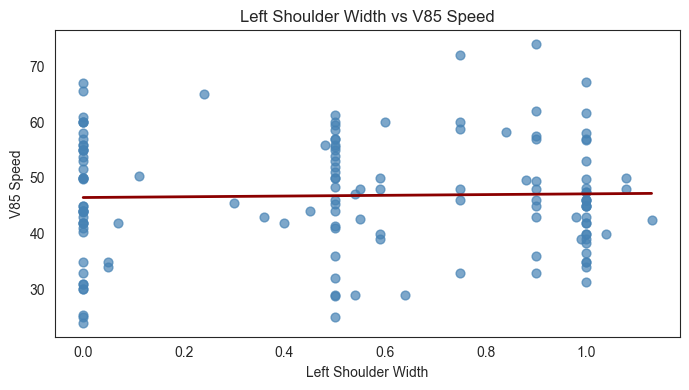

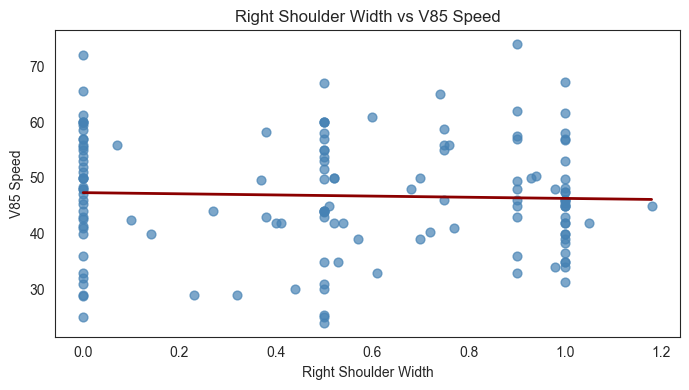

In [283]:
sns.set_style("white")

for col in predictor_cols:
    plt.figure(figsize=(7, 4))  # same size for each plot

    sns.regplot(
        x=df[col],
        y=df["V85 Speed"],
        scatter_kws={"s": 40, "color": "steelblue", "alpha": 0.7},
        line_kws={"color": "darkred", "linewidth": 2},
        ci=None  # no shaded region
    )

    plt.title(f"{col} vs V85 Speed")
    plt.xlabel(col)
    plt.ylabel("V85 Speed")

    plt.tight_layout()
    plt.show()

In [284]:
# Clean categorical text first (avoid space issues)
df["Left Shoulder Type"] = df["Left Shoulder Type"].str.strip()
df["Right Shoulder Type"] = df["Right Shoulder Type"].str.strip()

# Encode as numeric (no bool issue)
df_encoded = pd.get_dummies(
    df,
    columns=["Left Shoulder Type", "Right Shoulder Type"],
    drop_first=True,
    dtype=int
)
df_encoded.head()

,SN,V85 Speed,Gradient,Radius of Curve,Carriageway Width,Left Shoulder Width,Right Shoulder Width,Left Shoulder Type_Gravel,Left Shoulder Type_Paved,Right Shoulder Type_Gravel,Right Shoulder Type_Paved
0,1,57.0,1.27,1500,5.5,0.9,0.9,1,0,1,0
1,2,33.0,2.92,46,5.5,0.9,0.9,1,0,1,0
2,3,43.0,7.97,1500,5.5,0.9,0.9,1,0,1,0
3,4,48.0,2.07,1500,5.5,0.9,0.9,1,0,1,0
4,5,36.0,1.21,16,5.5,0.9,0.9,1,0,1,0


In [285]:
X_vif = df_encoded[
    [
        "Gradient",
        "Radius of Curve",
        "Carriageway Width",
        "Left Shoulder Width",
        "Right Shoulder Width",
        "Left Shoulder Type_Gravel",
        "Left Shoulder Type_Paved",
        "Right Shoulder Type_Gravel",
        "Right Shoulder Type_Paved"
    ]
]

In [286]:
X_vif = X_vif.astype(float)

In [287]:
import statsmodels.api as sm

X_vif_const = sm.add_constant(X_vif)
from statsmodels.stats.outliers_influence import variance_inflation_factor
import pandas as pd

vif_data = pd.DataFrame()
vif_data["Feature"] = X_vif_const.columns
vif_data["VIF"] = [
    variance_inflation_factor(X_vif_const.values, i)
    for i in range(X_vif_const.shape[1])
]
vif_data

,Feature,VIF
0,const,94.546368
1,Gradient,1.196435
2,Radius of Curve,1.071587
3,Carriageway Width,1.326701
4,Left Shoulder Width,5.131911
5,Right Shoulder Width,4.610753
6,Left Shoulder Type_Gravel,6.301732
7,Left Shoulder Type_Paved,5.791759
8,Right Shoulder Type_Gravel,5.244162
9,Right Shoulder Type_Paved,5.971506


In [288]:
X = df_encoded[
    [
        "Gradient",
        "Radius of Curve",
        "Carriageway Width",
        "Left Shoulder Width",
        "Right Shoulder Width",
        "Left Shoulder Type_Gravel",
        "Left Shoulder Type_Paved",
        "Right Shoulder Type_Gravel",
        "Right Shoulder Type_Paved"
    ]
]

y = df_encoded["V85 Speed"]

MLR MODEL

In [289]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=42
)

print("X_train shape:", X_train.shape)
print("X_test shape :", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape :", y_test.shape)

X_train shape: (112, 9)
X_test shape : (28, 9)
y_train shape: (112,)
y_test shape : (28,)


In [290]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Scaling completed")

Scaling completed


In [291]:
from sklearn.linear_model import LinearRegression

mlr = LinearRegression()
mlr.fit(X_train_scaled, y_train)

print("MLR model trained successfully")

MLR model trained successfully


In [292]:
y_train_pred_mlr = mlr.predict(X_train_scaled)
y_test_pred_mlr = mlr.predict(X_test_scaled)

In [293]:
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
import numpy as np
import pandas as pd

mlr_train_r2 = r2_score(y_train, y_train_pred_mlr)
mlr_test_r2 = r2_score(y_test, y_test_pred_mlr)

mlr_train_rmse = np.sqrt(mean_squared_error(y_train, y_train_pred_mlr))
mlr_test_rmse = np.sqrt(mean_squared_error(y_test, y_test_pred_mlr))

mlr_train_mae = mean_absolute_error(y_train, y_train_pred_mlr)
mlr_test_mae = mean_absolute_error(y_test, y_test_pred_mlr)

mlr_results = pd.DataFrame({
    "Metric": ["R2", "RMSE", "MAE"],
    "Value": [mlr_test_r2, mlr_test_rmse, mlr_test_mae]
})

mlr_results

,Metric,Value
0,R2,0.019261
1,RMSE,7.883553
2,MAE,6.298261


In [294]:
coef_table_mlr = pd.DataFrame({
    "Variable": X.columns,
    "Coefficient": mlr.coef_
})

# Add intercept as first row
intercept_row = pd.DataFrame({
    "Variable": ["Constant"],
    "Coefficient": [mlr.intercept_]
})

coef_table_mlr = pd.concat([intercept_row, coef_table_mlr], ignore_index=True)

coef_table_mlr["Coefficient"] = coef_table_mlr["Coefficient"].round(4)

coef_table_mlr

,Variable,Coefficient
0,Constant,46.8826
1,Gradient,0.4325
2,Radius of Curve,5.9868
3,Carriageway Width,-0.1504
4,Left Shoulder Width,0.1425
5,Right Shoulder Width,0.5005
6,Left Shoulder Type_Gravel,-0.4672
7,Left Shoulder Type_Paved,-0.5615
8,Right Shoulder Type_Gravel,-2.3106
9,Right Shoulder Type_Paved,-0.4940


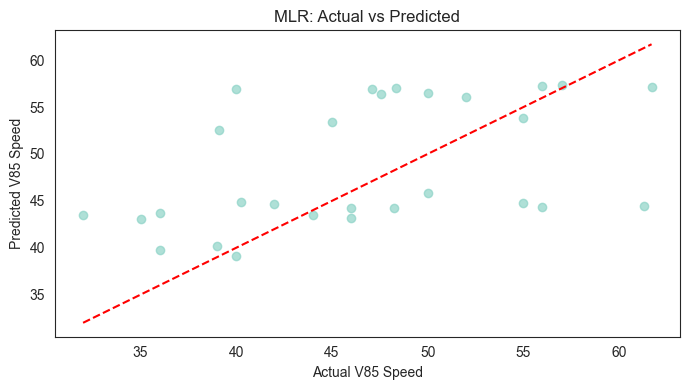

In [295]:
import matplotlib.pyplot as plt

plt.figure(figsize=(7, 4))
plt.scatter(y_test, y_test_pred_mlr, alpha=0.7)
plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    'r--'
)
plt.xlabel("Actual V85 Speed")
plt.ylabel("Predicted V85 Speed")
plt.title("MLR: Actual vs Predicted")
plt.tight_layout()
plt.show()

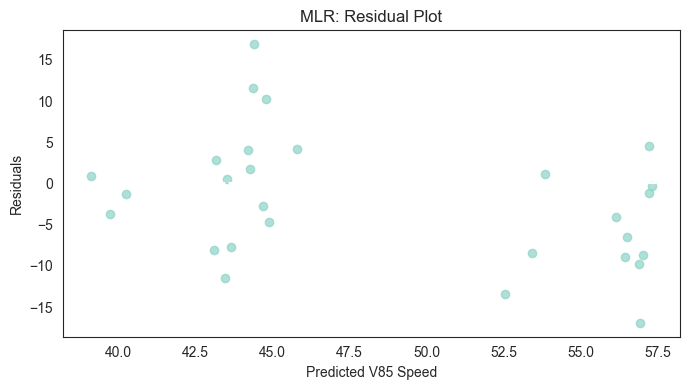

In [296]:
mlr_residuals = y_test - y_test_pred_mlr

plt.figure(figsize=(7, 4))
plt.scatter(y_test_pred_mlr, mlr_residuals, alpha=0.7)
plt.axhline(y=0, linestyle="--")
plt.xlabel("Predicted V85 Speed")
plt.ylabel("Residuals")
plt.title("MLR: Residual Plot")
plt.tight_layout()
plt.show()

In [297]:
mlr_final = pd.DataFrame({
    "Model": ["MLR"],
    "R2": [round(mlr_test_r2, 3)],
    "RMSE": [round(mlr_test_rmse, 3)],
    "MAE": [round(mlr_test_mae, 3)]
})

mlr_final

,Model,R2,RMSE,MAE
0,MLR,0.019,7.884,6.298


RANDOM FOREST

In [298]:
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(
    random_state=42
)

rf.fit(X_train_scaled, y_train)

print("Base Random Forest model trained successfully")

Base Random Forest model trained successfully


In [299]:
y_train_pred_rf = rf.predict(X_train_scaled)
y_test_pred_rf = rf.predict(X_test_scaled)

In [300]:
rf_train_r2 = r2_score(y_train, y_train_pred_rf)
rf_test_r2 = r2_score(y_test, y_test_pred_rf)

rf_train_rmse = np.sqrt(mean_squared_error(y_train, y_train_pred_rf))
rf_test_rmse = np.sqrt(mean_squared_error(y_test, y_test_pred_rf))

rf_train_mae = mean_absolute_error(y_train, y_train_pred_rf)
rf_test_mae = mean_absolute_error(y_test, y_test_pred_rf)

rf_results = pd.DataFrame({
    "Metric": ["R2", "RMSE", "MAE"],
    "Value": [rf_test_r2, rf_test_rmse, rf_test_mae]
})

rf_results

,Metric,Value
0,R2,0.078786
1,RMSE,7.640563
2,MAE,6.189125


In [301]:
rf_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": rf.feature_importances_
}).sort_values(by="Importance", ascending=False)

rf_importance

,Feature,Importance
1,Radius of Curve,0.550381
0,Gradient,0.220190
4,Right Shoulder Width,0.062511
3,Left Shoulder Width,0.055577
2,Carriageway Width,0.049160
5,Left Shoulder Type_Gravel,0.019010
7,Right Shoulder Type_Gravel,0.016720
6,Left Shoulder Type_Paved,0.013829
8,Right Shoulder Type_Paved,0.012622


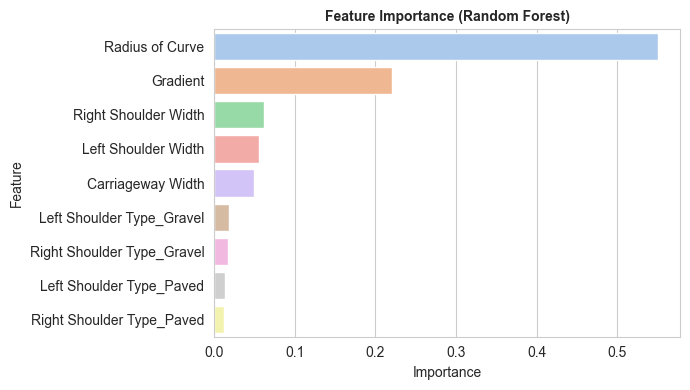

In [302]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")

plt.figure(figsize=(7, 4))

sns.barplot(
    x="Importance",
    y="Feature",
    data=rf_importance,  # make sure this matches your dataframe
    palette="pastel"
)

plt.title("Feature Importance (Random Forest)", fontsize=10, fontweight="bold")
plt.xlabel("Importance")
plt.ylabel("Feature")

plt.tight_layout()
plt.show()

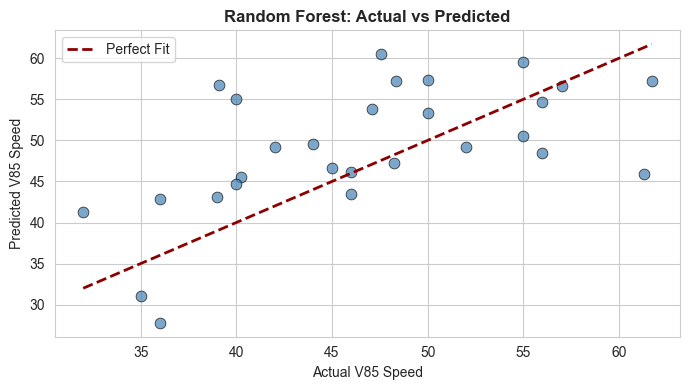

In [303]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")

plt.figure(figsize=(7, 4))

# Scatter plot using seaborn
sns.scatterplot(
    x=y_test,
    y=y_test_pred_rf,
    color="steelblue",
    s=60,
    alpha=0.7,
    edgecolor="black"
)

# Perfect fit line (45-degree line)
plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    color="darkred",
    linestyle="--",
    linewidth=2,
    label="Perfect Fit"
)

plt.xlabel("Actual V85 Speed")
plt.ylabel("Predicted V85 Speed")
plt.title("Random Forest: Actual vs Predicted", fontsize=12, fontweight="bold")

plt.legend()
plt.tight_layout()
plt.show()

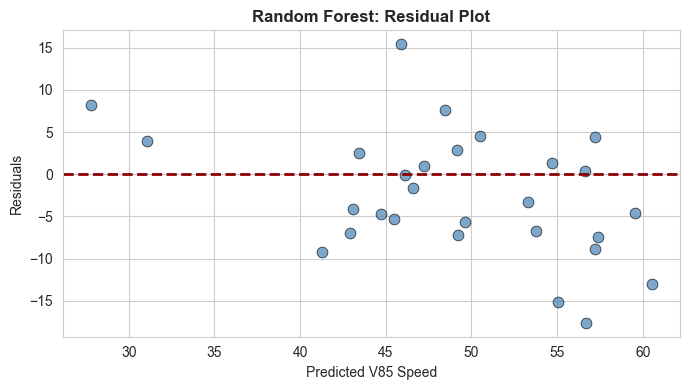

In [304]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_style("whitegrid")

rf_residuals = y_test - y_test_pred_rf

plt.figure(figsize=(7, 4))

sns.scatterplot(
    x=y_test_pred_rf,
    y=rf_residuals,
    color="steelblue",
    s=60,
    alpha=0.7,
    edgecolor="black"
)

plt.axhline(y=0, linestyle="--", color="darkred", linewidth=2)

plt.xlabel("Predicted V85 Speed")
plt.ylabel("Residuals")
plt.title("Random Forest: Residual Plot", fontsize=12, fontweight="bold")

plt.tight_layout()
plt.show()

In [305]:
rf_final = pd.DataFrame({
    "Model": ["Random Forest"],
    "R2": [round(rf_test_r2, 3)],
    "RMSE": [round(rf_test_rmse, 3)],
    "MAE": [round(rf_test_mae, 3)]
})

rf_final

,Model,R2,RMSE,MAE
0,Random Forest,0.079,7.641,6.189


TUNED RANDOM FOREST

In [306]:
param_grid_rf = {
    "n_estimators": [100, 200, 300],
    "max_depth": [None, 5, 10, 15],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4],
    "max_features": ["sqrt", "log2"]
}

In [307]:
from sklearn.model_selection import GridSearchCV

grid_rf = GridSearchCV(
    estimator=RandomForestRegressor(random_state=42),
    param_grid=param_grid_rf,
    cv=5,
    scoring="r2",
    n_jobs=-1,
    verbose=1
)

grid_rf.fit(X_train_scaled, y_train)

print("Tuning completed")
print("Best Parameters:", grid_rf.best_params_)
print("Best CV Score:", round(grid_rf.best_score_, 3))

Fitting 5 folds for each of 216 candidates, totalling 1080 fits
Tuning completed
Best Parameters: {'max_depth': None, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'min_samples_split': 5, 'n_estimators': 100}
Best CV Score: 0.304


In [308]:
best_rf = grid_rf.best_estimator_
best_rf

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""squared_error"", ""absolute_error"", ""friedman_mse"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in Poisson deviance to find splits.Training using ""absolute_error"" is significantly slowerthan when using ""squared_error""... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",5
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsam

In [309]:
y_train_pred_rf_tuned = best_rf.predict(X_train_scaled)
y_test_pred_rf_tuned = best_rf.predict(X_test_scaled)

In [310]:
rf_tuned_train_r2 = r2_score(y_train, y_train_pred_rf_tuned)
rf_tuned_test_r2 = r2_score(y_test, y_test_pred_rf_tuned)

rf_tuned_train_rmse = np.sqrt(mean_squared_error(y_train, y_train_pred_rf_tuned))
rf_tuned_test_rmse = np.sqrt(mean_squared_error(y_test, y_test_pred_rf_tuned))

rf_tuned_train_mae = mean_absolute_error(y_train, y_train_pred_rf_tuned)
rf_tuned_test_mae = mean_absolute_error(y_test, y_test_pred_rf_tuned)

rf_tuned_results = pd.DataFrame({
    "Metric": ["R2", "RMSE", "MAE"],
    "Value": [rf_tuned_test_r2, rf_tuned_test_rmse, rf_tuned_test_mae]
})

rf_tuned_results

,Metric,Value
0,R2,0.347901
1,RMSE,6.428385
2,MAE,4.916684


In [311]:
rf_tuned_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": best_rf.feature_importances_
}).sort_values(by="Importance", ascending=False)

rf_tuned_importance

,Feature,Importance
1,Radius of Curve,0.505684
0,Gradient,0.229731
4,Right Shoulder Width,0.070782
3,Left Shoulder Width,0.065594
2,Carriageway Width,0.054070
5,Left Shoulder Type_Gravel,0.021891
7,Right Shoulder Type_Gravel,0.021354
6,Left Shoulder Type_Paved,0.015619
8,Right Shoulder Type_Paved,0.015276


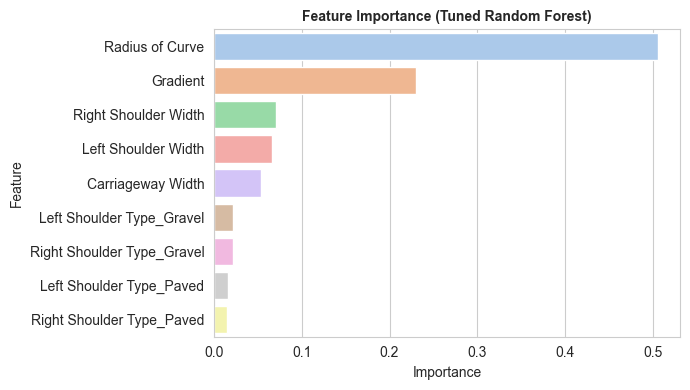

In [312]:
sns.set_style("whitegrid")

plt.figure(figsize=(7, 4))

sns.barplot(
    x="Importance",
    y="Feature",
    data=rf_tuned_importance,
    palette="pastel"
)

plt.title("Feature Importance (Tuned Random Forest)", fontsize=10, fontweight="bold")
plt.xlabel("Importance")
plt.ylabel("Feature")

plt.tight_layout()
plt.show()

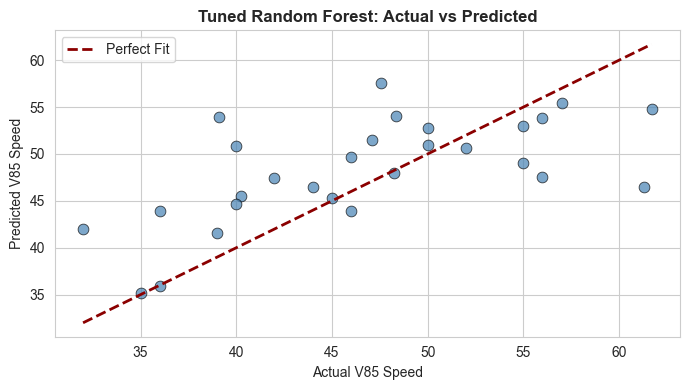

In [313]:
sns.set_style("whitegrid")

plt.figure(figsize=(7, 4))

sns.scatterplot(
    x=y_test,
    y=y_test_pred_rf_tuned,
    color="steelblue",
    s=60,
    alpha=0.7,
    edgecolor="black"
)

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    color="darkred",
    linestyle="--",
    linewidth=2,
    label="Perfect Fit"
)

plt.xlabel("Actual V85 Speed")
plt.ylabel("Predicted V85 Speed")
plt.title("Tuned Random Forest: Actual vs Predicted", fontsize=12, fontweight="bold")

plt.legend()
plt.tight_layout()
plt.show()

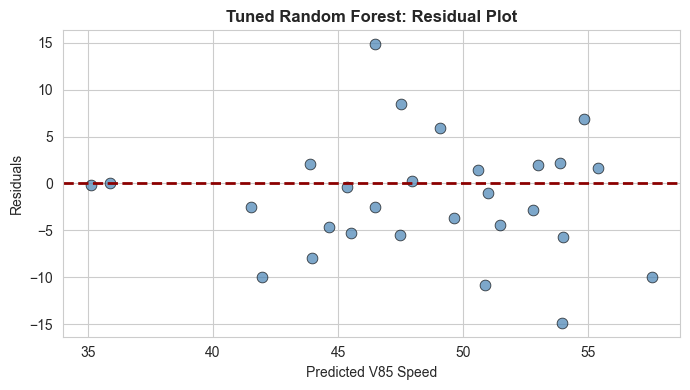

In [314]:
rf_tuned_residuals = y_test - y_test_pred_rf_tuned

sns.set_style("whitegrid")

plt.figure(figsize=(7, 4))

sns.scatterplot(
    x=y_test_pred_rf_tuned,
    y=rf_tuned_residuals,
    color="steelblue",
    s=60,
    alpha=0.7,
    edgecolor="black"
)

plt.axhline(y=0, linestyle="--", color="darkred", linewidth=2)

plt.xlabel("Predicted V85 Speed")
plt.ylabel("Residuals")
plt.title("Tuned Random Forest: Residual Plot", fontsize=12, fontweight="bold")

plt.tight_layout()
plt.show()

In [315]:
rf_tuned_final = pd.DataFrame({
    "Model": ["Tuned Random Forest"],
    "R2": [round(rf_tuned_test_r2, 3)],
    "RMSE": [round(rf_tuned_test_rmse, 3)],
    "MAE": [round(rf_tuned_test_mae, 3)]
})

rf_tuned_final

,Model,R2,RMSE,MAE
0,Tuned Random Forest,0.348,6.428,4.917


In [316]:
rf_comparison = pd.concat([rf_final, rf_tuned_final], ignore_index=True)
rf_comparison

,Model,R2,RMSE,MAE
0,Random Forest,0.079,7.641,6.189
1,Tuned Random Forest,0.348,6.428,4.917


In [317]:
best_rf_params = pd.DataFrame(
    list(grid_rf.best_params_.items()),
    columns=["Parameter", "Best Value"]
)

best_rf_params

,Parameter,Best Value
0,max_depth,None
1,max_features,sqrt
2,min_samples_leaf,1
3,min_samples_split,5
4,n_estimators,100


XGBOOST MODEL

In [318]:
from xgboost import XGBRegressor

xgb = XGBRegressor(
    random_state=42,
    objective="reg:squarederror"
)

xgb.fit(X_train_scaled, y_train)

print("Base XGBoost model trained successfully")

Base XGBoost model trained successfully


In [319]:
y_train_pred_xgb = xgb.predict(X_train_scaled)
y_test_pred_xgb = xgb.predict(X_test_scaled)

In [320]:
xgb_train_r2 = r2_score(y_train, y_train_pred_xgb)
xgb_test_r2 = r2_score(y_test, y_test_pred_xgb)

xgb_train_rmse = np.sqrt(mean_squared_error(y_train, y_train_pred_xgb))
xgb_test_rmse = np.sqrt(mean_squared_error(y_test, y_test_pred_xgb))

xgb_train_mae = mean_absolute_error(y_train, y_train_pred_xgb)
xgb_test_mae = mean_absolute_error(y_test, y_test_pred_xgb)

xgb_results = pd.DataFrame({
    "Metric": ["R2", "RMSE", "MAE"],
    "Value": [xgb_test_r2, xgb_test_rmse, xgb_test_mae]
})

xgb_results

,Metric,Value
0,R2,-0.309504
1,RMSE,9.109586
2,MAE,7.508751


In [321]:
xgb_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": xgb.feature_importances_
}).sort_values(by="Importance", ascending=False)

xgb_importance

,Feature,Importance
1,Radius of Curve,0.342905
8,Right Shoulder Type_Paved,0.148012
7,Right Shoulder Type_Gravel,0.135455
4,Right Shoulder Width,0.102888
2,Carriageway Width,0.069748
3,Left Shoulder Width,0.067840
5,Left Shoulder Type_Gravel,0.060822
0,Gradient,0.048974
6,Left Shoulder Type_Paved,0.023356


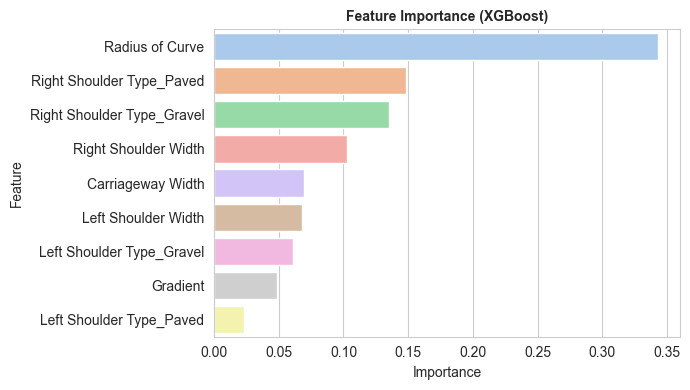

In [322]:
sns.set_style("whitegrid")

plt.figure(figsize=(7, 4))

sns.barplot(
    x="Importance",
    y="Feature",
    data=xgb_importance,
    palette="pastel"
)

plt.title("Feature Importance (XGBoost)", fontsize=10, fontweight="bold")
plt.xlabel("Importance")
plt.ylabel("Feature")

plt.tight_layout()
plt.show()

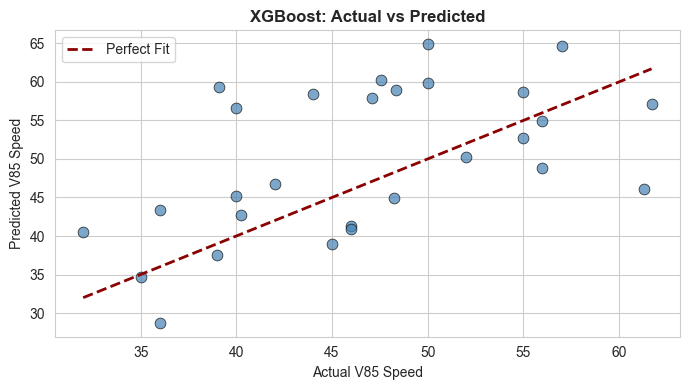

In [323]:
sns.set_style("whitegrid")

plt.figure(figsize=(7, 4))

sns.scatterplot(
    x=y_test,
    y=y_test_pred_xgb,
    color="steelblue",
    s=60,
    alpha=0.7,
    edgecolor="black"
)

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    color="darkred",
    linestyle="--",
    linewidth=2,
    label="Perfect Fit"
)

plt.xlabel("Actual V85 Speed")
plt.ylabel("Predicted V85 Speed")
plt.title("XGBoost: Actual vs Predicted", fontsize=12, fontweight="bold")

plt.legend()
plt.tight_layout()
plt.show()

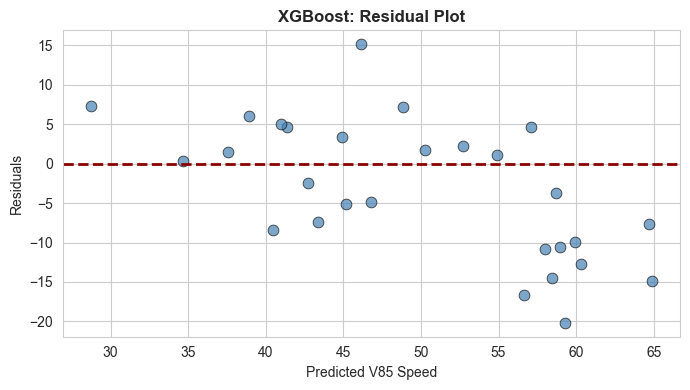

In [324]:
xgb_residuals = y_test - y_test_pred_xgb

sns.set_style("whitegrid")

plt.figure(figsize=(7, 4))
sns.scatterplot(
    x=y_test_pred_xgb,
    y=xgb_residuals,
    color="steelblue",
    s=60,
    alpha=0.7,
    edgecolor="black"
)

plt.axhline(y=0, linestyle="--", color="darkred", linewidth=2)

plt.xlabel("Predicted V85 Speed")
plt.ylabel("Residuals")
plt.title("XGBoost: Residual Plot", fontsize=12, fontweight="bold")

plt.tight_layout()
plt.show()

In [325]:
xgb_final = pd.DataFrame({
    "Model": ["XGBoost"],
    "R2": [round(xgb_test_r2, 3)],
    "RMSE": [round(xgb_test_rmse, 3)],
    "MAE": [round(xgb_test_mae, 3)]
})

xgb_final

,Model,R2,RMSE,MAE
0,XGBoost,-0.31,9.11,7.509


TUNED XGBOOST MODEL

In [326]:
param_grid_xgb = {
    "n_estimators": [100, 200],
    "max_depth": [3, 4, 5],
    "learning_rate": [0.01, 0.05, 0.1],
    "subsample": [0.7, 0.8, 1.0],
    "colsample_bytree": [0.7, 0.8, 1.0]
}

In [327]:
grid_xgb = GridSearchCV(
    estimator=XGBRegressor(
        random_state=42,
        objective="reg:squarederror"
    ),
    param_grid=param_grid_xgb,
    cv=5,
    scoring="r2",
    n_jobs=-1,
    verbose=1
)

grid_xgb.fit(X_train_scaled, y_train)

print("Best Parameters:", grid_xgb.best_params_)
print("Best CV Score:", round(grid_xgb.best_score_, 3))

Fitting 5 folds for each of 162 candidates, totalling 810 fits
Best Parameters: {'colsample_bytree': 0.8, 'learning_rate': 0.01, 'max_depth': 3, 'n_estimators': 200, 'subsample': 1.0}
Best CV Score: 0.319


In [328]:
best_xgb = grid_xgb.best_estimator_

y_train_pred_xgb_tuned = best_xgb.predict(X_train_scaled)
y_test_pred_xgb_tuned = best_xgb.predict(X_test_scaled)

In [329]:
xgb_tuned_train_r2 = r2_score(y_train, y_train_pred_xgb_tuned)
xgb_tuned_test_r2 = r2_score(y_test, y_test_pred_xgb_tuned)

xgb_tuned_train_rmse = np.sqrt(mean_squared_error(y_train, y_train_pred_xgb_tuned))
xgb_tuned_test_rmse = np.sqrt(mean_squared_error(y_test, y_test_pred_xgb_tuned))

xgb_tuned_train_mae = mean_absolute_error(y_train, y_train_pred_xgb_tuned)
xgb_tuned_test_mae = mean_absolute_error(y_test, y_test_pred_xgb_tuned)

xgb_tuned_results = pd.DataFrame({
    "Metric": ["R2", "RMSE", "MAE"],
    "Value": [xgb_tuned_test_r2, xgb_tuned_test_rmse, xgb_tuned_test_mae]
})

xgb_tuned_results

,Metric,Value
0,R2,0.258762
1,RMSE,6.853684
2,MAE,5.418310


In [330]:
xgb_tuned_final = pd.DataFrame({
    "Model": ["Tuned XGBoost"],
    "R2": [round(xgb_tuned_test_r2, 3)],
    "RMSE": [round(xgb_tuned_test_rmse, 3)],
    "MAE": [round(xgb_tuned_test_mae, 3)]
})

xgb_tuned_final

,Model,R2,RMSE,MAE
0,Tuned XGBoost,0.259,6.854,5.418


In [331]:
xgb_comparison = pd.concat([xgb_final, xgb_tuned_final], ignore_index=True)
xgb_comparison

,Model,R2,RMSE,MAE
0,XGBoost,-0.310,9.110,7.509
1,Tuned XGBoost,0.259,6.854,5.418


In [332]:
xgb_tuned_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": best_xgb.feature_importances_
})

# Sort from highest to lowest importance
xgb_tuned_importance = xgb_tuned_importance.sort_values(
    by="Importance",
    ascending=False
).reset_index(drop=True)

# Round values for better presentation
xgb_tuned_importance["Importance"] = xgb_tuned_importance["Importance"].round(4)

xgb_tuned_importance

,Feature,Importance
0,Radius of Curve,0.3300
1,Right Shoulder Type_Paved,0.1203
2,Gradient,0.0980
3,Right Shoulder Width,0.0931
4,Right Shoulder Type_Gravel,0.0890
5,Carriageway Width,0.0739
6,Left Shoulder Type_Paved,0.0717
7,Left Shoulder Type_Gravel,0.0664
8,Left Shoulder Width,0.0576


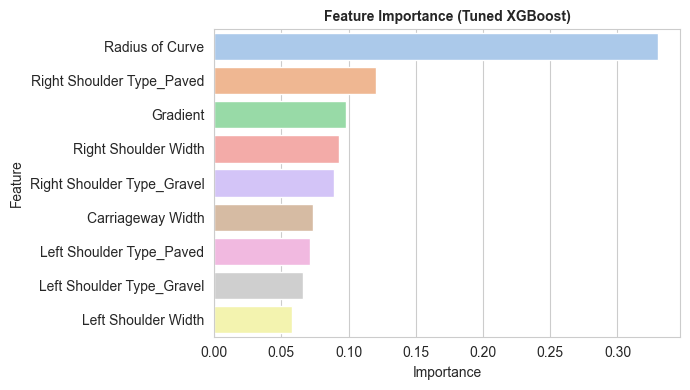

In [333]:
sns.set_style("whitegrid")

# Sort properly (important)
xgb_tuned_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": best_xgb.feature_importances_
}).sort_values(by="Importance", ascending=False)

plt.figure(figsize=(7, 4))

sns.barplot(
    x="Importance",
    y="Feature",
    data=xgb_tuned_importance,
    palette="pastel"
)

plt.title("Feature Importance (Tuned XGBoost)", fontsize=10, fontweight="bold")
plt.xlabel("Importance")
plt.ylabel("Feature")

plt.tight_layout()
plt.show()

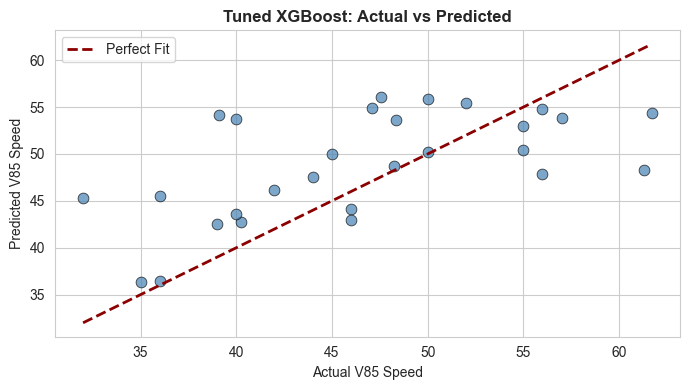

In [334]:
sns.set_style("whitegrid")

plt.figure(figsize=(7, 4))

sns.scatterplot(
    x=y_test,
    y=y_test_pred_xgb_tuned,
    color="steelblue",
    s=60,
    alpha=0.7,
    edgecolor="black"
)

# Perfect fit line
plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    color="darkred",
    linestyle="--",
    linewidth=2,
    label="Perfect Fit"
)

plt.xlabel("Actual V85 Speed")
plt.ylabel("Predicted V85 Speed")
plt.title("Tuned XGBoost: Actual vs Predicted", fontsize=12, fontweight="bold")

plt.legend()
plt.tight_layout()
plt.show()

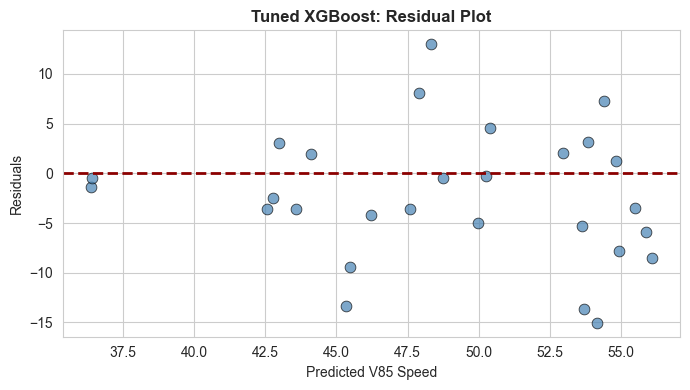

In [335]:
xgb_tuned_residuals = y_test - y_test_pred_xgb_tuned

sns.set_style("whitegrid")

plt.figure(figsize=(7, 4))

sns.scatterplot(
    x=y_test_pred_xgb_tuned,
    y=xgb_tuned_residuals,
    color="steelblue",
    s=60,
    alpha=0.7,
    edgecolor="black"
)

plt.axhline(y=0, linestyle="--", color="darkred", linewidth=2)

plt.xlabel("Predicted V85 Speed")
plt.ylabel("Residuals")
plt.title("Tuned XGBoost: Residual Plot", fontsize=12, fontweight="bold")

plt.tight_layout()
plt.show()

In [336]:
best_xgb_params = pd.DataFrame(
    list(grid_xgb.best_params_.items()),
    columns=["Parameter", "Best Value"]
)

best_xgb_params

,Parameter,Best Value
0,colsample_bytree,0.80
1,learning_rate,0.01
2,max_depth,3.00
3,n_estimators,200.00
4,subsample,1.00


SUPPORT VECTOR REGRESSION MODEL

In [337]:
from sklearn.svm import SVR

svr = SVR(
    kernel="rbf",
    C=100,
    epsilon=0.1,
    gamma="scale"
)

svr.fit(X_train_scaled, y_train)

print("Base SVR model trained successfully")

Base SVR model trained successfully


In [338]:
y_train_pred_svr = svr.predict(X_train_scaled)
y_test_pred_svr = svr.predict(X_test_scaled)

In [339]:
svr_train_r2 = r2_score(y_train, y_train_pred_svr)
svr_test_r2 = r2_score(y_test, y_test_pred_svr)

svr_train_rmse = np.sqrt(mean_squared_error(y_train, y_train_pred_svr))
svr_test_rmse = np.sqrt(mean_squared_error(y_test, y_test_pred_svr))

svr_train_mae = mean_absolute_error(y_train, y_train_pred_svr)
svr_test_mae = mean_absolute_error(y_test, y_test_pred_svr)

svr_results = pd.DataFrame({
    "Metric": ["R2", "RMSE", "MAE"],
    "Value": [svr_test_r2, svr_test_rmse, svr_test_mae]
})

svr_results

,Metric,Value
0,R2,-0.170758
1,RMSE,8.613481
2,MAE,6.369260


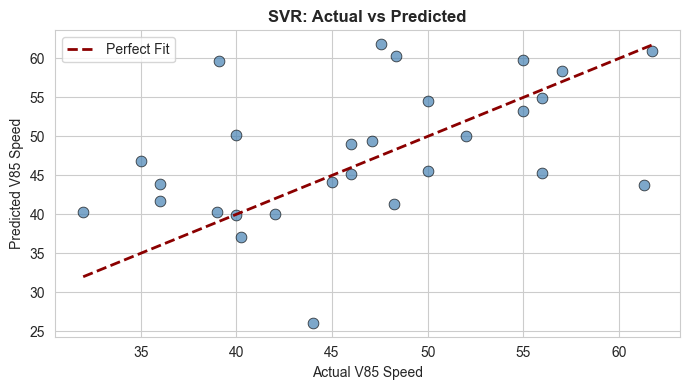

In [340]:
sns.set_style("whitegrid")

plt.figure(figsize=(7, 4))

sns.scatterplot(
    x=y_test,
    y=y_test_pred_svr,
    color="steelblue",
    s=60,
    alpha=0.7,
    edgecolor="black"
)

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    color="darkred",
    linestyle="--",
    linewidth=2,
    label="Perfect Fit"
)

plt.xlabel("Actual V85 Speed")
plt.ylabel("Predicted V85 Speed")
plt.title("SVR: Actual vs Predicted", fontsize=12, fontweight="bold")

plt.legend()
plt.tight_layout()
plt.show()

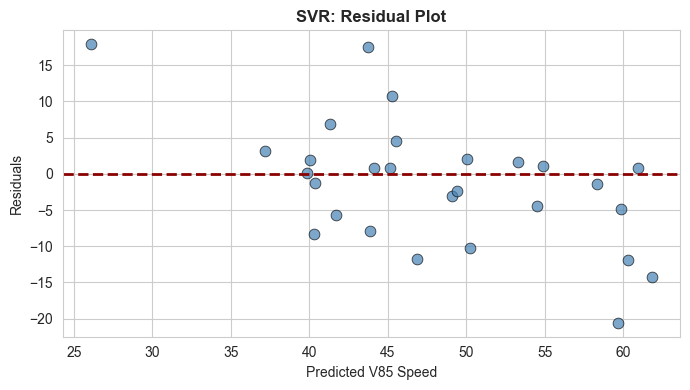

In [341]:
svr_residuals = y_test - y_test_pred_svr

sns.set_style("whitegrid")

plt.figure(figsize=(7, 4))

sns.scatterplot(
    x=y_test_pred_svr,
    y=svr_residuals,
    color="steelblue",
    s=60,
    alpha=0.7,
    edgecolor="black"
)

plt.axhline(y=0, linestyle="--", color="darkred", linewidth=2)

plt.xlabel("Predicted V85 Speed")
plt.ylabel("Residuals")
plt.title("SVR: Residual Plot", fontsize=12, fontweight="bold")

plt.tight_layout()
plt.show()

In [342]:
svr_final = pd.DataFrame({
    "Model": ["SVR"],
    "R2": [round(svr_test_r2, 3)],
    "RMSE": [round(svr_test_rmse, 3)],
    "MAE": [round(svr_test_mae, 3)]
})

svr_final

,Model,R2,RMSE,MAE
0,SVR,-0.171,8.613,6.369


TUNED SVR MODEL

In [343]:
param_grid_svr = {
    "C": [1, 10, 100, 1000],
    "epsilon": [0.01, 0.1, 0.5, 1],
    "gamma": ["scale", 0.01, 0.1, 1],
    "kernel": ["rbf"]
}

In [344]:
grid_svr = GridSearchCV(
    estimator=SVR(),
    param_grid=param_grid_svr,
    cv=5,
    scoring="r2",
    n_jobs=-1,
    verbose=1
)

grid_svr.fit(X_train_scaled, y_train)

print("Best Parameters:", grid_svr.best_params_)
print("Best CV Score:", round(grid_svr.best_score_, 3))

Fitting 5 folds for each of 64 candidates, totalling 320 fits
Best Parameters: {'C': 10, 'epsilon': 1, 'gamma': 0.01, 'kernel': 'rbf'}
Best CV Score: 0.099


In [345]:
best_svr = grid_svr.best_estimator_

y_train_pred_svr_tuned = best_svr.predict(X_train_scaled)
y_test_pred_svr_tuned = best_svr.predict(X_test_scaled)

In [346]:
svr_tuned_train_r2 = r2_score(y_train, y_train_pred_svr_tuned)
svr_tuned_test_r2 = r2_score(y_test, y_test_pred_svr_tuned)

svr_tuned_train_rmse = np.sqrt(mean_squared_error(y_train, y_train_pred_svr_tuned))
svr_tuned_test_rmse = np.sqrt(mean_squared_error(y_test, y_test_pred_svr_tuned))

svr_tuned_train_mae = mean_absolute_error(y_train, y_train_pred_svr_tuned)
svr_tuned_test_mae = mean_absolute_error(y_test, y_test_pred_svr_tuned)

svr_tuned_results = pd.DataFrame({
    "Metric": ["R2", "RMSE", "MAE"],
    "Value": [svr_tuned_test_r2, svr_tuned_test_rmse, svr_tuned_test_mae]
})

svr_tuned_results

,Metric,Value
0,R2,0.060749
1,RMSE,7.715003
2,MAE,6.451164


In [347]:
svr_tuned_final = pd.DataFrame({
    "Model": ["Tuned SVR"],
    "R2": [round(svr_tuned_test_r2, 3)],
    "RMSE": [round(svr_tuned_test_rmse, 3)],
    "MAE": [round(svr_tuned_test_mae, 3)]
})

svr_tuned_final

,Model,R2,RMSE,MAE
0,Tuned SVR,0.061,7.715,6.451


In [348]:
svr_comparison = pd.concat([svr_final, svr_tuned_final], ignore_index=True)
svr_comparison

,Model,R2,RMSE,MAE
0,SVR,-0.171,8.613,6.369
1,Tuned SVR,0.061,7.715,6.451


In [349]:
best_svr_params = pd.DataFrame(
    list(grid_svr.best_params_.items()),
    columns=["Parameter", "Best Value"]
)

best_svr_params

,Parameter,Best Value
0,C,10
1,epsilon,1
2,gamma,0.01
3,kernel,rbf


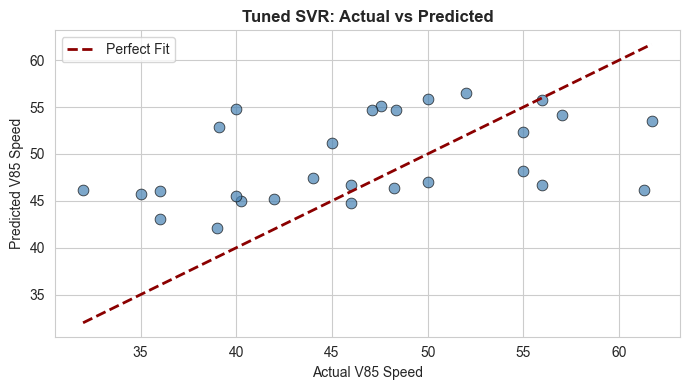

In [350]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_style("whitegrid")

plt.figure(figsize=(7, 4))

sns.scatterplot(
    x=y_test,
    y=y_test_pred_svr_tuned,
    color="steelblue",
    s=60,
    alpha=0.7,
    edgecolor="black"
)

# Perfect fit line
plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    color="darkred",
    linestyle="--",
    linewidth=2,
    label="Perfect Fit"
)

plt.xlabel("Actual V85 Speed")
plt.ylabel("Predicted V85 Speed")
plt.title("Tuned SVR: Actual vs Predicted", fontsize=12, fontweight="bold")

plt.legend()
plt.tight_layout()
plt.show()

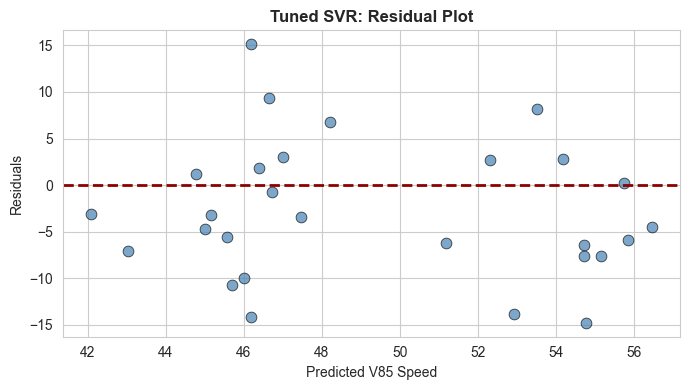

In [351]:
svr_tuned_residuals = y_test - y_test_pred_svr_tuned

sns.set_style("whitegrid")

plt.figure(figsize=(7, 4))

sns.scatterplot(
    x=y_test_pred_svr_tuned,
    y=svr_tuned_residuals,
    color="steelblue",
    s=60,
    alpha=0.7,
    edgecolor="black"
)

plt.axhline(y=0, linestyle="--", color="darkred", linewidth=2)

plt.xlabel("Predicted V85 Speed")
plt.ylabel("Residuals")
plt.title("Tuned SVR: Residual Plot", fontsize=12, fontweight="bold")

plt.tight_layout()
plt.show()

ARTIFICIAL NEURAL NETWORK MODEL

In [352]:
from sklearn.neural_network import MLPRegressor

ann = MLPRegressor(
    hidden_layer_sizes=(64, 32),
    activation="relu",
    solver="adam",
    alpha=0.001,
    learning_rate_init=0.01,
    max_iter=2000,
    random_state=42
)

ann.fit(X_train_scaled, y_train)

print("Base ANN model trained successfully")

Base ANN model trained successfully


In [353]:
y_train_pred_ann = ann.predict(X_train_scaled)
y_test_pred_ann = ann.predict(X_test_scaled)

In [354]:
ann_train_r2 = r2_score(y_train, y_train_pred_ann)
ann_test_r2 = r2_score(y_test, y_test_pred_ann)

ann_train_rmse = np.sqrt(mean_squared_error(y_train, y_train_pred_ann))
ann_test_rmse = np.sqrt(mean_squared_error(y_test, y_test_pred_ann))

ann_train_mae = mean_absolute_error(y_train, y_train_pred_ann)
ann_test_mae = mean_absolute_error(y_test, y_test_pred_ann)

ann_results = pd.DataFrame({
    "Metric": ["R2", "RMSE", "MAE"],
    "Value": [ann_test_r2, ann_test_rmse, ann_test_mae]
})

ann_results

,Metric,Value
0,R2,-0.027881
1,RMSE,8.070800
2,MAE,6.439610


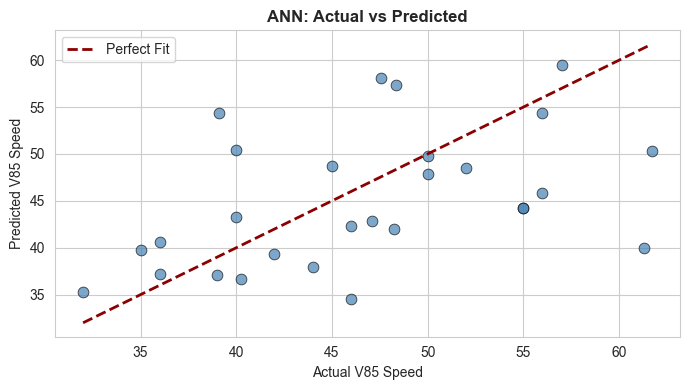

In [355]:
sns.set_style("whitegrid")

plt.figure(figsize=(7, 4))

sns.scatterplot(
    x=y_test,
    y=y_test_pred_ann,
    color="steelblue",
    s=60,
    alpha=0.7,
    edgecolor="black"
)

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    color="darkred",
    linestyle="--",
    linewidth=2,
    label="Perfect Fit"
)

plt.xlabel("Actual V85 Speed")
plt.ylabel("Predicted V85 Speed")
plt.title("ANN: Actual vs Predicted", fontsize=12, fontweight="bold")

plt.legend()
plt.tight_layout()
plt.show()

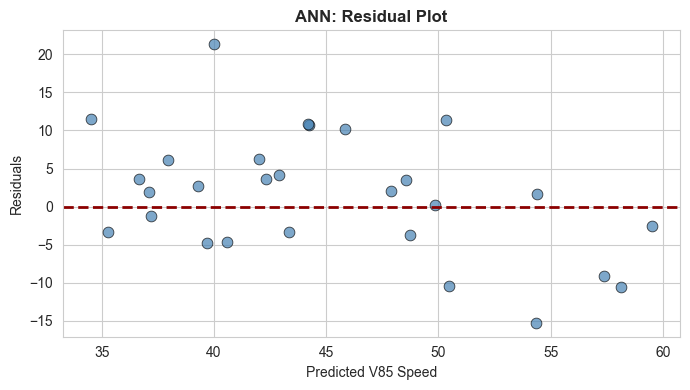

In [356]:
ann_residuals = y_test - y_test_pred_ann

sns.set_style("whitegrid")

plt.figure(figsize=(7, 4))

sns.scatterplot(
    x=y_test_pred_ann,
    y=ann_residuals,
    color="steelblue",
    s=60,
    alpha=0.7,
    edgecolor="black"
)

plt.axhline(y=0, linestyle="--", color="darkred", linewidth=2)

plt.xlabel("Predicted V85 Speed")
plt.ylabel("Residuals")
plt.title("ANN: Residual Plot", fontsize=12, fontweight="bold")

plt.tight_layout()
plt.show()

In [357]:
ann_final = pd.DataFrame({
    "Model": ["ANN"],
    "R2": [round(ann_test_r2, 3)],
    "RMSE": [round(ann_test_rmse, 3)],
    "MAE": [round(ann_test_mae, 3)]
})

ann_final

,Model,R2,RMSE,MAE
0,ANN,-0.028,8.071,6.44


TUNED ANN MODEL

In [358]:
param_grid_ann = {
    "hidden_layer_sizes": [(32,), (64,), (64, 32), (128, 64)],
    "activation": ["relu", "tanh"],
    "alpha": [0.0001, 0.001, 0.01],
    "learning_rate_init": [0.001, 0.01]
}

In [359]:
grid_ann = GridSearchCV(
    estimator=MLPRegressor(
        max_iter=3000,
        random_state=42
    ),
    param_grid=param_grid_ann,
    cv=5,
    scoring="r2",
    n_jobs=-1,
    verbose=1
)

grid_ann.fit(X_train_scaled, y_train)

print("Best Parameters:", grid_ann.best_params_)
print("Best CV Score:", round(grid_ann.best_score_, 3))

Fitting 5 folds for each of 48 candidates, totalling 240 fits
Best Parameters: {'activation': 'tanh', 'alpha': 0.01, 'hidden_layer_sizes': (32,), 'learning_rate_init': 0.001}
Best CV Score: -0.058


In [360]:
best_ann = grid_ann.best_estimator_

y_train_pred_ann_tuned = best_ann.predict(X_train_scaled)
y_test_pred_ann_tuned = best_ann.predict(X_test_scaled)

In [361]:
ann_tuned_train_r2 = r2_score(y_train, y_train_pred_ann_tuned)
ann_tuned_test_r2 = r2_score(y_test, y_test_pred_ann_tuned)

ann_tuned_train_rmse = np.sqrt(mean_squared_error(y_train, y_train_pred_ann_tuned))
ann_tuned_test_rmse = np.sqrt(mean_squared_error(y_test, y_test_pred_ann_tuned))

ann_tuned_train_mae = mean_absolute_error(y_train, y_train_pred_ann_tuned)
ann_tuned_test_mae = mean_absolute_error(y_test, y_test_pred_ann_tuned)

ann_tuned_results = pd.DataFrame({
    "Metric": ["R2", "RMSE", "MAE"],
    "Value": [ann_tuned_test_r2, ann_tuned_test_rmse, ann_tuned_test_mae]
})

ann_tuned_results

,Metric,Value
0,R2,0.158600
1,RMSE,7.302079
2,MAE,5.824389


In [362]:
ann_tuned_final = pd.DataFrame({
    "Model": ["Tuned ANN"],
    "R2": [round(ann_tuned_test_r2, 3)],
    "RMSE": [round(ann_tuned_test_rmse, 3)],
    "MAE": [round(ann_tuned_test_mae, 3)]
})

ann_tuned_final

,Model,R2,RMSE,MAE
0,Tuned ANN,0.159,7.302,5.824


In [363]:
ann_comparison = pd.concat([ann_final, ann_tuned_final], ignore_index=True)
ann_comparison

,Model,R2,RMSE,MAE
0,ANN,-0.028,8.071,6.440
1,Tuned ANN,0.159,7.302,5.824


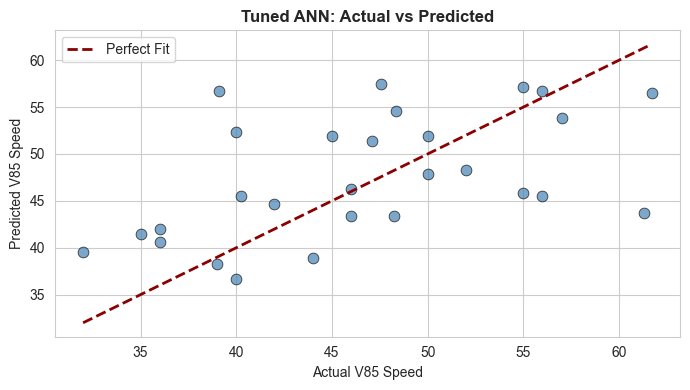

In [364]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_style("whitegrid")

plt.figure(figsize=(7, 4))

sns.scatterplot(
    x=y_test,
    y=y_test_pred_ann_tuned,
    color="steelblue",
    s=60,
    alpha=0.7,
    edgecolor="black"
)

# Perfect fit line
plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    color="darkred",
    linestyle="--",
    linewidth=2,
    label="Perfect Fit"
)

plt.xlabel("Actual V85 Speed")
plt.ylabel("Predicted V85 Speed")
plt.title("Tuned ANN: Actual vs Predicted", fontsize=12, fontweight="bold")

plt.legend()
plt.tight_layout()
plt.show()

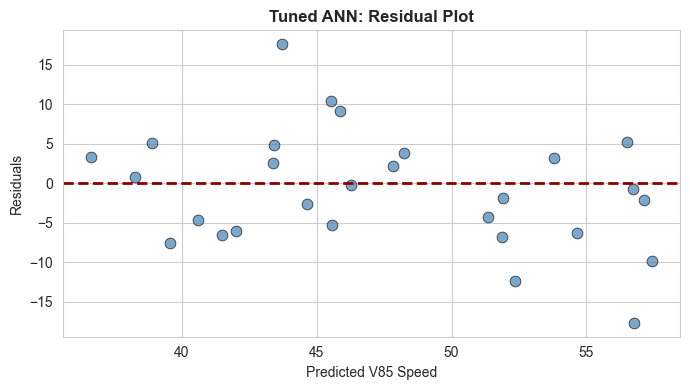

In [365]:
ann_tuned_residuals = y_test - y_test_pred_ann_tuned

sns.set_style("whitegrid")

plt.figure(figsize=(7, 4))

sns.scatterplot(
    x=y_test_pred_ann_tuned,
    y=ann_tuned_residuals,
    color="steelblue",
    s=60,
    alpha=0.7,
    edgecolor="black"
)

plt.axhline(y=0, linestyle="--", color="darkred", linewidth=2)

plt.xlabel("Predicted V85 Speed")
plt.ylabel("Residuals")
plt.title("Tuned ANN: Residual Plot", fontsize=12, fontweight="bold")

plt.tight_layout()
plt.show()

In [366]:
best_ann_params = pd.DataFrame(
    list(grid_ann.best_params_.items()),
    columns=["Parameter", "Best Value"]
)

best_ann_params

,Parameter,Best Value
0,activation,tanh
1,alpha,0.01
2,hidden_layer_sizes,"(32,)"
3,learning_rate_init,0.001


In [367]:
import pandas as pd

# Step 1: Add Type column properly
mlr_final["Type"] = "Base"

svr_final["Type"] = "Base"
svr_tuned_final["Type"] = "Tuned"

ann_final["Type"] = "Base"
ann_tuned_final["Type"] = "Tuned"

xgb_final["Type"] = "Base"
xgb_tuned_final["Type"] = "Tuned"

rf_final["Type"] = "Base"
rf_tuned_final["Type"] = "Tuned"

# Step 2: Combine all models
master_table = pd.concat([
    mlr_final,
    svr_final,
    svr_tuned_final,
    ann_final,
    ann_tuned_final,
    xgb_final,
    xgb_tuned_final,
    rf_final,
    rf_tuned_final
], ignore_index=True)

# Step 3: Arrange columns
master_table = master_table[["Model", "Type", "R2", "RMSE", "MAE"]]

# Step 4: Round values
master_table["R2"] = master_table["R2"].round(3)
master_table["RMSE"] = master_table["RMSE"].round(3)
master_table["MAE"] = master_table["MAE"].round(3)

# Step 5: Sort by RMSE (LOWEST = BEST)
master_table = master_table.sort_values(
    by="RMSE",
    ascending=True
).reset_index(drop=True)

# Step 6: Add ranking
master_table["Rank (RMSE)"] = range(1, len(master_table) + 1)

# Step 7: Final column order
master_table = master_table[["Rank (RMSE)", "Model", "Type", "R2", "RMSE", "MAE"]]

master_table

,Rank (RMSE),Model,Type,R2,RMSE,MAE
0,1,Tuned Random Forest,Tuned,0.348,6.428,4.917
1,2,Tuned XGBoost,Tuned,0.259,6.854,5.418
2,3,Tuned ANN,Tuned,0.159,7.302,5.824
3,4,Random Forest,Base,0.079,7.641,6.189
4,5,Tuned SVR,Tuned,0.061,7.715,6.451
5,6,MLR,Base,0.019,7.884,6.298
6,7,ANN,Base,-0.028,8.071,6.440
7,8,SVR,Base,-0.171,8.613,6.369
8,9,XGBoost,Base,-0.310,9.110,7.509


-----------------------------------------------------------------------------------------------------------------------------------------------

MODEL WITHOUT SHOULDER TYPE VARIABLES

In [368]:
X_new = df_encoded[
    [
        "Gradient",
        "Radius of Curve",
        "Carriageway Width",
        "Left Shoulder Width",
        "Right Shoulder Width"
    ]
]

y_new = df_encoded["V85 Speed"]

In [369]:
from sklearn.model_selection import train_test_split

X_train_new, X_test_new, y_train_new, y_test_new = train_test_split(
    X_new, y_new,
    test_size=0.20,
    random_state=42
)

In [370]:
from sklearn.preprocessing import StandardScaler

scaler_new = StandardScaler()

X_train_scaled_new = scaler_new.fit_transform(X_train_new)
X_test_scaled_new = scaler_new.transform(X_test_new)

In [371]:
from sklearn.linear_model import LinearRegression

mlr_new = LinearRegression()
mlr_new.fit(X_train_scaled_new, y_train_new)

y_test_pred_mlr_new = mlr_new.predict(X_test_scaled_new)

mlr_r2_new = r2_score(y_test_new, y_test_pred_mlr_new)
mlr_rmse_new = np.sqrt(mean_squared_error(y_test_new, y_test_pred_mlr_new))
mlr_mae_new = mean_absolute_error(y_test_new, y_test_pred_mlr_new)

mlr_final_new = pd.DataFrame({
    "Model": ["MLR (No Type)"],
    "R2": [round(mlr_r2_new, 3)],
    "RMSE": [round(mlr_rmse_new, 3)],
    "MAE": [round(mlr_mae_new, 3)]
})

mlr_final_new

,Model,R2,RMSE,MAE
0,MLR (No Type),-0.002,7.97,6.473


In [372]:
rf_new = RandomForestRegressor(random_state=42)
rf_new.fit(X_train_scaled_new, y_train_new)

y_test_pred_rf_new = rf_new.predict(X_test_scaled_new)

rf_r2_new = r2_score(y_test_new, y_test_pred_rf_new)
rf_rmse_new = np.sqrt(mean_squared_error(y_test_new, y_test_pred_rf_new))
rf_mae_new = mean_absolute_error(y_test_new, y_test_pred_rf_new)

rf_final_new = pd.DataFrame({
    "Model": ["RF (No Type)"],
    "R2": [round(rf_r2_new, 3)],
    "RMSE": [round(rf_rmse_new, 3)],
    "MAE": [round(rf_mae_new, 3)]
})

rf_final_new

,Model,R2,RMSE,MAE
0,RF (No Type),0.091,7.589,6.208


In [373]:
grid_rf_new = GridSearchCV(
    estimator=RandomForestRegressor(random_state=42),
    param_grid=param_grid_rf,
    cv=5,
    scoring="r2",
    n_jobs=-1
)

grid_rf_new.fit(X_train_scaled_new, y_train_new)

best_rf_new = grid_rf_new.best_estimator_

y_test_pred_rf_tuned_new = best_rf_new.predict(X_test_scaled_new)

rf_tuned_r2_new = r2_score(y_test_new, y_test_pred_rf_tuned_new)
rf_tuned_rmse_new = np.sqrt(mean_squared_error(y_test_new, y_test_pred_rf_tuned_new))
rf_tuned_mae_new = mean_absolute_error(y_test_new, y_test_pred_rf_tuned_new)

rf_tuned_final_new = pd.DataFrame({
    "Model": ["Tuned RF (No Type)"],
    "R2": [round(rf_tuned_r2_new, 3)],
    "RMSE": [round(rf_tuned_rmse_new, 3)],
    "MAE": [round(rf_tuned_mae_new, 3)]
})

rf_tuned_final_new

,Model,R2,RMSE,MAE
0,Tuned RF (No Type),0.293,6.694,5.052


In [374]:
grid_xgb_new = GridSearchCV(
    estimator=XGBRegressor(random_state=42, objective="reg:squarederror"),
    param_grid=param_grid_xgb,
    cv=5,
    scoring="r2",
    n_jobs=-1
)

grid_xgb_new.fit(X_train_scaled_new, y_train_new)

best_xgb_new = grid_xgb_new.best_estimator_

y_test_pred_xgb_new = best_xgb_new.predict(X_test_scaled_new)

xgb_r2_new = r2_score(y_test_new, y_test_pred_xgb_new)
xgb_rmse_new = np.sqrt(mean_squared_error(y_test_new, y_test_pred_xgb_new))
xgb_mae_new = mean_absolute_error(y_test_new, y_test_pred_xgb_new)

xgb_final_new = pd.DataFrame({
    "Model": ["Tuned XGB (No Type)"],
    "R2": [round(xgb_r2_new, 3)],
    "RMSE": [round(xgb_rmse_new, 3)],
    "MAE": [round(xgb_mae_new, 3)]
})

xgb_final_new

,Model,R2,RMSE,MAE
0,Tuned XGB (No Type),0.279,6.757,5.166


In [375]:
param_grid_svr = {
    "C": [1, 10, 100, 1000],
    "epsilon": [0.01, 0.1, 0.5, 1],
    "gamma": ["scale", 0.01, 0.1, 1],
    "kernel": ["rbf"]
}

grid_svr_new = GridSearchCV(
    estimator=SVR(),
    param_grid=param_grid_svr,
    cv=5,
    scoring="r2",
    n_jobs=-1,
    verbose=1
)
grid_svr_new.fit(X_train_scaled_new, y_train_new)

best_svr_new = grid_svr_new.best_estimator_

y_test_pred_svr_new = best_svr_new.predict(X_test_scaled_new)

svr_r2_new = r2_score(y_test_new, y_test_pred_svr_new)
svr_rmse_new = np.sqrt(mean_squared_error(y_test_new, y_test_pred_svr_new))
svr_mae_new = mean_absolute_error(y_test_new, y_test_pred_svr_new)

svr_final_new = pd.DataFrame({
    "Model": ["Tuned SVR (No Type)"],
    "R2": [round(svr_r2_new, 3)],
    "RMSE": [round(svr_rmse_new, 3)],
    "MAE": [round(svr_mae_new, 3)]
})

svr_final_new

Fitting 5 folds for each of 64 candidates, totalling 320 fits


,Model,R2,RMSE,MAE
0,Tuned SVR (No Type),-0.196,8.706,7.012


In [376]:
grid_ann.fit(X_train_scaled_new, y_train_new)

best_ann_new = grid_ann.best_estimator_

y_test_pred_ann_new = best_ann_new.predict(X_test_scaled_new)

ann_r2_new = r2_score(y_test_new, y_test_pred_ann_new)
ann_rmse_new = np.sqrt(mean_squared_error(y_test_new, y_test_pred_ann_new))
ann_mae_new = mean_absolute_error(y_test_new, y_test_pred_ann_new)

ann_final_new = pd.DataFrame({
    "Model": ["Tuned ANN (No Type)"],
    "R2": [round(ann_r2_new, 3)],
    "RMSE": [round(ann_rmse_new, 3)],
    "MAE": [round(ann_mae_new, 3)]
})

ann_final_new

Fitting 5 folds for each of 48 candidates, totalling 240 fits


,Model,R2,RMSE,MAE
0,Tuned ANN (No Type),0.058,7.726,6.484


In [377]:
final_no_type = pd.concat([
    mlr_final_new,
    rf_tuned_final_new,
    xgb_final_new,
    ann_final_new,
    svr_final_new
], ignore_index=True)

final_no_type = final_no_type.sort_values(by="RMSE").reset_index(drop=True)

final_no_type

,Model,R2,RMSE,MAE
0,Tuned RF (No Type),0.293,6.694,5.052
1,Tuned XGB (No Type),0.279,6.757,5.166
2,Tuned ANN (No Type),0.058,7.726,6.484
3,MLR (No Type),-0.002,7.970,6.473
4,Tuned SVR (No Type),-0.196,8.706,7.012


---------------------------------------------------------------------------------------------------------------------------------------------

AVERAGE SHOULDER WIDTH

In [378]:
# Create average shoulder width
df_encoded["Avg Shoulder Width"] = (
                                           df_encoded["Left Shoulder Width"] + df_encoded["Right Shoulder Width"]
                                   ) / 2

In [379]:
# Define predictors and target
X_avg = df_encoded[
    [
        "Gradient",
        "Radius of Curve",
        "Carriageway Width",
        "Avg Shoulder Width"
    ]
]

y_avg = df_encoded["V85 Speed"]

In [380]:
# Train-test split
X_train_avg, X_test_avg, y_train_avg, y_test_avg = train_test_split(
    X_avg, y_avg,
    test_size=0.20,
    random_state=42
)

print("X_train_avg shape:", X_train_avg.shape)
print("X_test_avg shape :", X_test_avg.shape)
print("y_train_avg shape:", y_train_avg.shape)
print("y_test_avg shape :", y_test_avg.shape)

X_train_avg shape: (112, 4)
X_test_avg shape : (28, 4)
y_train_avg shape: (112,)
y_test_avg shape : (28,)


In [381]:
# Scaling
scaler_avg = StandardScaler()

X_train_scaled_avg = scaler_avg.fit_transform(X_train_avg)
X_test_scaled_avg = scaler_avg.transform(X_test_avg)

print("Scaling completed for average shoulder width case")

Scaling completed for average shoulder width case


In [382]:
mlr_avg = LinearRegression()
mlr_avg.fit(X_train_scaled_avg, y_train_avg)

y_test_pred_mlr_avg = mlr_avg.predict(X_test_scaled_avg)

mlr_r2_avg = r2_score(y_test_avg, y_test_pred_mlr_avg)
mlr_rmse_avg = np.sqrt(mean_squared_error(y_test_avg, y_test_pred_mlr_avg))
mlr_mae_avg = mean_absolute_error(y_test_avg, y_test_pred_mlr_avg)

mlr_final_avg = pd.DataFrame({
    "Model": ["MLR (Avg Shoulder)"],
    "R2": [round(mlr_r2_avg, 3)],
    "RMSE": [round(mlr_rmse_avg, 3)],
    "MAE": [round(mlr_mae_avg, 3)]
})

mlr_final_avg

,Model,R2,RMSE,MAE
0,MLR (Avg Shoulder),-0.004,7.975,6.489


In [383]:
grid_rf_avg = GridSearchCV(
    estimator=RandomForestRegressor(random_state=42),
    param_grid=param_grid_rf,
    cv=5,
    scoring="r2",
    n_jobs=-1,
    verbose=1
)

grid_rf_avg.fit(X_train_scaled_avg, y_train_avg)

print("Best Parameters:", grid_rf_avg.best_params_)
print("Best CV Score:", round(grid_rf_avg.best_score_, 3))

Fitting 5 folds for each of 216 candidates, totalling 1080 fits
Best Parameters: {'max_depth': None, 'max_features': 'sqrt', 'min_samples_leaf': 4, 'min_samples_split': 10, 'n_estimators': 100}
Best CV Score: 0.316


In [384]:
best_rf_avg = grid_rf_avg.best_estimator_

y_test_pred_rf_avg = best_rf_avg.predict(X_test_scaled_avg)

rf_r2_avg = r2_score(y_test_avg, y_test_pred_rf_avg)
rf_rmse_avg = np.sqrt(mean_squared_error(y_test_avg, y_test_pred_rf_avg))
rf_mae_avg = mean_absolute_error(y_test_avg, y_test_pred_rf_avg)

rf_final_avg = pd.DataFrame({
    "Model": ["Tuned RF (Avg Shoulder)"],
    "R2": [round(rf_r2_avg, 3)],
    "RMSE": [round(rf_rmse_avg, 3)],
    "MAE": [round(rf_mae_avg, 3)]
})

print(rf_final_avg)

                     Model     R2   RMSE    MAE
0  Tuned RF (Avg Shoulder)  0.369  6.321  4.708


In [385]:
best_rf_params_avg = pd.DataFrame(
    list(grid_rf_avg.best_params_.items()),
    columns=["Parameter", "Best Value"]
)

best_rf_params_avg

,Parameter,Best Value
0,max_depth,None
1,max_features,sqrt
2,min_samples_leaf,4
3,min_samples_split,10
4,n_estimators,100


In [386]:
grid_xgb_avg = GridSearchCV(
    estimator=XGBRegressor(
        random_state=42,
        objective="reg:squarederror"
    ),
    param_grid=param_grid_xgb,
    cv=5,
    scoring="r2",
    n_jobs=-1,
    verbose=1
)

grid_xgb_avg.fit(X_train_scaled_avg, y_train_avg)

print("Best Parameters:", grid_xgb_avg.best_params_)
print("Best CV Score:", round(grid_xgb_avg.best_score_, 3))
best_xgb_avg = grid_xgb_avg.best_estimator_

y_test_pred_xgb_avg = best_xgb_avg.predict(X_test_scaled_avg)

xgb_r2_avg = r2_score(y_test_avg, y_test_pred_xgb_avg)
xgb_rmse_avg = np.sqrt(mean_squared_error(y_test_avg, y_test_pred_xgb_avg))
xgb_mae_avg = mean_absolute_error(y_test_avg, y_test_pred_xgb_avg)

xgb_final_avg = pd.DataFrame({
    "Model": ["Tuned XGBoost (Avg Shoulder)"],
    "R2": [round(xgb_r2_avg, 3)],
    "RMSE": [round(xgb_rmse_avg, 3)],
    "MAE": [round(xgb_mae_avg, 3)]
})

print(xgb_final_avg)
best_xgb_params_avg = pd.DataFrame(
    list(grid_xgb_avg.best_params_.items()),
    columns=["Parameter", "Best Value"]
)

best_xgb_params_avg

Fitting 5 folds for each of 162 candidates, totalling 810 fits
Best Parameters: {'colsample_bytree': 0.8, 'learning_rate': 0.01, 'max_depth': 3, 'n_estimators': 200, 'subsample': 0.8}
Best CV Score: 0.307
                          Model     R2   RMSE    MAE
0  Tuned XGBoost (Avg Shoulder)  0.269  6.804  5.226


,Parameter,Best Value
0,colsample_bytree,0.80
1,learning_rate,0.01
2,max_depth,3.00
3,n_estimators,200.00
4,subsample,0.80


In [387]:
grid_svr_avg = GridSearchCV(
    estimator=SVR(),
    param_grid=param_grid_svr,
    cv=5,
    scoring="r2",
    n_jobs=-1,
    verbose=1
)

grid_svr_avg.fit(X_train_scaled_avg, y_train_avg)

print("Best Parameters:", grid_svr_avg.best_params_)
print("Best CV Score:", round(grid_svr_avg.best_score_, 3))
best_svr_avg = grid_svr_avg.best_estimator_

y_test_pred_svr_avg = best_svr_avg.predict(X_test_scaled_avg)

svr_r2_avg = r2_score(y_test_avg, y_test_pred_svr_avg)
svr_rmse_avg = np.sqrt(mean_squared_error(y_test_avg, y_test_pred_svr_avg))
svr_mae_avg = mean_absolute_error(y_test_avg, y_test_pred_svr_avg)

svr_final_avg = pd.DataFrame({
    "Model": ["Tuned SVR (Avg Shoulder)"],
    "R2": [round(svr_r2_avg, 3)],
    "RMSE": [round(svr_rmse_avg, 3)],
    "MAE": [round(svr_mae_avg, 3)]
})

print(svr_final_avg)
best_svr_params_avg = pd.DataFrame(
    list(grid_svr_avg.best_params_.items()),
    columns=["Parameter", "Best Value"]
)

best_svr_params_avg

Fitting 5 folds for each of 64 candidates, totalling 320 fits
Best Parameters: {'C': 100, 'epsilon': 0.01, 'gamma': 0.01, 'kernel': 'rbf'}
Best CV Score: 0.189
                      Model     R2   RMSE    MAE
0  Tuned SVR (Avg Shoulder) -0.168  8.602  7.036


,Parameter,Best Value
0,C,100
1,epsilon,0.01
2,gamma,0.01
3,kernel,rbf


In [388]:
grid_ann_avg = GridSearchCV(
    estimator=MLPRegressor(
        max_iter=3000,
        random_state=42
    ),
    param_grid=param_grid_ann,
    cv=5,
    scoring="r2",
    n_jobs=-1,
    verbose=1
)

grid_ann_avg.fit(X_train_scaled_avg, y_train_avg)

print("Best Parameters:", grid_ann_avg.best_params_)
print("Best CV Score:", round(grid_ann_avg.best_score_, 3))
best_ann_avg = grid_ann_avg.best_estimator_

y_test_pred_ann_avg = best_ann_avg.predict(X_test_scaled_avg)

ann_r2_avg = r2_score(y_test_avg, y_test_pred_ann_avg)
ann_rmse_avg = np.sqrt(mean_squared_error(y_test_avg, y_test_pred_ann_avg))
ann_mae_avg = mean_absolute_error(y_test_avg, y_test_pred_ann_avg)

ann_final_avg = pd.DataFrame({
    "Model": ["Tuned ANN (Avg Shoulder)"],
    "R2": [round(ann_r2_avg, 3)],
    "RMSE": [round(ann_rmse_avg, 3)],
    "MAE": [round(ann_mae_avg, 3)]
})

print(ann_final_avg)
best_ann_params_avg = pd.DataFrame(
    list(grid_ann_avg.best_params_.items()),
    columns=["Parameter", "Best Value"]
)

best_ann_params_avg

Fitting 5 folds for each of 48 candidates, totalling 240 fits
Best Parameters: {'activation': 'tanh', 'alpha': 0.0001, 'hidden_layer_sizes': (64, 32), 'learning_rate_init': 0.001}
Best CV Score: 0.159
                      Model     R2   RMSE    MAE
0  Tuned ANN (Avg Shoulder)  0.369  6.325  4.863


,Parameter,Best Value
0,activation,tanh
1,alpha,0.0001
2,hidden_layer_sizes,"(64, 32)"
3,learning_rate_init,0.001


In [389]:
final_all_comparison = pd.DataFrame({
    "Model": ["MLR", "SVR", "ANN", "XGBoost", "Random Forest"],

    # Case 1: WITH SHOULDER TYPE
    "RMSE (With Type)": [
        mlr_final["RMSE"].values[0],
        svr_tuned_final["RMSE"].values[0],
        ann_tuned_final["RMSE"].values[0],
        xgb_tuned_final["RMSE"].values[0],
        rf_tuned_final["RMSE"].values[0]
    ],

    "R2 (With Type)": [
        mlr_final["R2"].values[0],
        svr_tuned_final["R2"].values[0],
        ann_tuned_final["R2"].values[0],
        xgb_tuned_final["R2"].values[0],
        rf_tuned_final["R2"].values[0]
    ],

    # Case 2: WITHOUT SHOULDER TYPE
    "RMSE (No Type)": [
        mlr_final_new["RMSE"].values[0],
        svr_final_new["RMSE"].values[0],
        ann_final_new["RMSE"].values[0],
        xgb_final_new["RMSE"].values[0],
        rf_tuned_final_new["RMSE"].values[0]
    ],

    "R2 (No Type)": [
        mlr_final_new["R2"].values[0],
        svr_final_new["R2"].values[0],
        ann_final_new["R2"].values[0],
        xgb_final_new["R2"].values[0],
        rf_tuned_final_new["R2"].values[0]
    ],

    # Case 3: AVG SHOULDER WIDTH
    "RMSE (Avg Shoulder)": [
        mlr_final_avg["RMSE"].values[0],
        svr_final_avg["RMSE"].values[0],
        ann_final_avg["RMSE"].values[0],
        xgb_final_avg["RMSE"].values[0],
        rf_final_avg["RMSE"].values[0]
    ],

    "R2 (Avg Shoulder)": [
        mlr_final_avg["R2"].values[0],
        svr_final_avg["R2"].values[0],
        ann_final_avg["R2"].values[0],
        xgb_final_avg["R2"].values[0],
        rf_final_avg["R2"].values[0]
    ]
})

final_all_comparison

,Model,RMSE (With Type),R2 (With Type),RMSE (No Type),R2 (No Type),RMSE (Avg Shoulder),R2 (Avg Shoulder)
0,MLR,7.884,0.019,7.970,-0.002,7.975,-0.004
1,SVR,7.715,0.061,8.706,-0.196,8.602,-0.168
2,ANN,7.302,0.159,7.726,0.058,6.325,0.369
3,XGBoost,6.854,0.259,6.757,0.279,6.804,0.269
4,Random Forest,6.428,0.348,6.694,0.293,6.321,0.369


In [390]:
import pandas as pd

# -------------------------------
# CASE 1: WITH SHOULDER TYPE
# -------------------------------
case1 = pd.DataFrame({
    "Model": [
        "MLR",
        "SVR (Base)", "SVR (Tuned)",
        "ANN (Base)", "ANN (Tuned)",
        "XGBoost (Base)", "XGBoost (Tuned)",
        "Random Forest (Base)", "Random Forest (Tuned)"
    ],
    "Case": "With Type",
    "R2": [
        mlr_final["R2"].values[0],
        svr_final["R2"].values[0], svr_tuned_final["R2"].values[0],
        ann_final["R2"].values[0], ann_tuned_final["R2"].values[0],
        xgb_final["R2"].values[0], xgb_tuned_final["R2"].values[0],
        rf_final["R2"].values[0], rf_tuned_final["R2"].values[0]
    ],
    "RMSE": [
        mlr_final["RMSE"].values[0],
        svr_final["RMSE"].values[0], svr_tuned_final["RMSE"].values[0],
        ann_final["RMSE"].values[0], ann_tuned_final["RMSE"].values[0],
        xgb_final["RMSE"].values[0], xgb_tuned_final["RMSE"].values[0],
        rf_final["RMSE"].values[0], rf_tuned_final["RMSE"].values[0]
    ],
    "MAE": [
        mlr_final["MAE"].values[0],
        svr_final["MAE"].values[0], svr_tuned_final["MAE"].values[0],
        ann_final["MAE"].values[0], ann_tuned_final["MAE"].values[0],
        xgb_final["MAE"].values[0], xgb_tuned_final["MAE"].values[0],
        rf_final["MAE"].values[0], rf_tuned_final["MAE"].values[0]
    ]
})

# -------------------------------
# CASE 2: WITHOUT SHOULDER TYPE
# -------------------------------
case2 = pd.DataFrame({
    "Model": [
        "MLR", "SVR", "ANN", "XGBoost", "Random Forest"
    ],
    "Case": "No Type",
    "R2": [
        mlr_final_new["R2"].values[0],
        svr_final_new["R2"].values[0],
        ann_final_new["R2"].values[0],
        xgb_final_new["R2"].values[0],
        rf_tuned_final_new["R2"].values[0]
    ],
    "RMSE": [
        mlr_final_new["RMSE"].values[0],
        svr_final_new["RMSE"].values[0],
        ann_final_new["RMSE"].values[0],
        xgb_final_new["RMSE"].values[0],
        rf_tuned_final_new["RMSE"].values[0]
    ],
    "MAE": [
        mlr_final_new["MAE"].values[0],
        svr_final_new["MAE"].values[0],
        ann_final_new["MAE"].values[0],
        xgb_final_new["MAE"].values[0],
        rf_tuned_final_new["MAE"].values[0]
    ]
})

# -------------------------------
# CASE 3: AVG SHOULDER WIDTH
# -------------------------------
case3 = pd.DataFrame({
    "Model": [
        "MLR", "SVR", "ANN", "XGBoost", "Random Forest"
    ],
    "Case": "Avg Shoulder",
    "R2": [
        mlr_final_avg["R2"].values[0],
        svr_final_avg["R2"].values[0],
        ann_final_avg["R2"].values[0],
        xgb_final_avg["R2"].values[0],
        rf_final_avg["R2"].values[0]
    ],
    "RMSE": [
        mlr_final_avg["RMSE"].values[0],
        svr_final_avg["RMSE"].values[0],
        ann_final_avg["RMSE"].values[0],
        xgb_final_avg["RMSE"].values[0],
        rf_final_avg["RMSE"].values[0]
    ],
    "MAE": [
        mlr_final_avg["MAE"].values[0],
        svr_final_avg["MAE"].values[0],
        ann_final_avg["MAE"].values[0],
        xgb_final_avg["MAE"].values[0],
        rf_final_avg["MAE"].values[0]
    ]
})

# -------------------------------
# COMBINE ALL
# -------------------------------
final_master_all = pd.concat([case1, case2, case3], ignore_index=True)

# Round values
final_master_all["R2"] = final_master_all["R2"].round(3)
final_master_all["RMSE"] = final_master_all["RMSE"].round(3)
final_master_all["MAE"] = final_master_all["MAE"].round(3)

# Rank based on RMSE
final_master_all = final_master_all.sort_values(by="RMSE").reset_index(drop=True)
final_master_all["Rank (RMSE)"] = range(1, len(final_master_all) + 1)

# Final format
final_master_all = final_master_all[
    ["Rank (RMSE)", "Model", "Case", "R2", "RMSE", "MAE"]
]

final_master_all

,Rank (RMSE),Model,Case,R2,RMSE,MAE
0,1,Random Forest,Avg Shoulder,0.369,6.321,4.708
1,2,ANN,Avg Shoulder,0.369,6.325,4.863
2,3,Random Forest (Tuned),With Type,0.348,6.428,4.917
3,4,Random Forest,No Type,0.293,6.694,5.052
4,5,XGBoost,No Type,0.279,6.757,5.166
5,6,XGBoost,Avg Shoulder,0.269,6.804,5.226
6,7,XGBoost (Tuned),With Type,0.259,6.854,5.418
7,8,ANN (Tuned),With Type,0.159,7.302,5.824
8,9,Random Forest (Base),With Type,0.079,7.641,6.189
9,10,SVR (Tuned),With Type,0.061,7.715,6.451
